<a href="https://colab.research.google.com/github/sandydiamantino/retailrocket-topsis/blob/main/retailrocket_topsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark de Recomendação com Grafo e TOPSIS

Este notebook apresenta um experimento inicial de recomendação de produtos
utilizando o dataset Retailrocket.

O objetivo é comparar:

1. Uma ordenação simples dos produtos candidatos.
2. Uma ordenação multicritério utilizando o método TOPSIS.

## Trabalhando com Dados Amostrais

## Etapa 1: Análise Exploratória dos Dados

Nesta etapa será realizada a análise exploratória dos dados.

### Importando as bibliotecas

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


### Definindo os links Raw

In [30]:
EVENTS_URL = (
    'https://raw.githubusercontent.com/sandydiamantino/retailrocket-topsis/refs/heads/main/data/sample_events.csv'
)

PROPERTIES_URL = (
    'https://raw.githubusercontent.com/sandydiamantino/retailrocket-topsis/refs/heads/main/data/sample_item_properties.csv'
)

print('Links definidos.')

Links definidos.


### Testando os links Raw

In [31]:
import requests

urls = {
    'events': EVENTS_URL,
    'properties': PROPERTIES_URL
}

for name, url in urls.items():
    response = requests.get(url)

    print(f'{name}: status HTTP {response.status_code}')

    if response.status_code == 200:
        print('  Link acessível.')
    else:
        print('  Verifique o link, o nome do arquivo ou a visibilidade do repositório.')

events: status HTTP 200
  Link acessível.
properties: status HTTP 200
  Link acessível.


### Carregando os arquivos

In [32]:
events = pd.read_csv(EVENTS_URL)

properties = pd.read_csv(PROPERTIES_URL)

print('Arquivos carregados com sucesso.')

Arquivos carregados com sucesso.


### Verificando o tamanho das tabelas

In [33]:
print('Tabela de eventos:')
print(f'Linhas: {events.shape[0]:,}')
print(f'Colunas: {events.shape[1]}')

print('\nTabela de propriedades:')
print(f'Linhas: {properties.shape[0]:,}')
print(f'Colunas: {properties.shape[1]}')

Tabela de eventos:
Linhas: 9,385
Colunas: 6

Tabela de propriedades:
Linhas: 392,648
Colunas: 4


### Visualizando as primeiras linhas

In [34]:
# Os eventos
display(events.head())

,timestamp,visitorid,event,itemid,transactionid,datetime
0,1433193132535,1134473,view,396045,NaN,2015-06-01 21:12:12.535
1,1433194696771,1314862,view,344224,NaN,2015-06-01 21:38:16.771
2,1433220848630,467124,view,396318,NaN,2015-06-02 04:54:08.630
3,1433218109710,1121229,view,370889,NaN,2015-06-02 04:08:29.710
4,1433178802896,39027,view,26210,NaN,2015-06-01 17:13:22.896


In [35]:
# As propriedades
display(properties.head())

,timestamp,itemid,property,value
0,1431831600000,156781,917,828513
1,1433646000000,272201,790,n10320.000
2,1440298800000,368230,400,1297729 n720.000 1178208 n900.000 424566
3,1431831600000,329408,888,1333963 747375 927741 1071593 547687 199524
4,1431831600000,103584,790,n459360.000


### Verificando os nomes das colunas

In [36]:
print('Colunas da tabela de eventos:')
print(events.columns.tolist())

print('\nColunas da tabela de propriedades:')
print(properties.columns.tolist())

Colunas da tabela de eventos:
['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'datetime']

Colunas da tabela de propriedades:
['timestamp', 'itemid', 'property', 'value']


### Verificando os tipos das colunas

In [37]:
print('Tipos das colunas de eventos:')
display(events.dtypes.to_frame('tipo'))

print('Tipos das colunas de propriedades:')
display(properties.dtypes.to_frame('tipo'))

Tipos das colunas de eventos:


,tipo
timestamp,int64
visitorid,int64
event,object
itemid,int64
transactionid,float64
datetime,object


Tipos das colunas de propriedades:


,tipo
timestamp,int64
itemid,int64
property,object
value,object


### Garantindo a coluna de data

In [38]:
if 'datetime' not in events.columns:
    events['datetime'] = pd.to_datetime(
        events['timestamp'],
        unit='ms'
    )
else:
    events['datetime'] = pd.to_datetime(
        events['datetime'],
        errors='coerce'
    )

print(events['datetime'].dtype)
display(events[['timestamp', 'datetime']].head())

datetime64[ns]


,timestamp,datetime
0,1433193132535,2015-06-01 21:12:12.535
1,1433194696771,2015-06-01 21:38:16.771
2,1433220848630,2015-06-02 04:54:08.630
3,1433218109710,2015-06-02 04:08:29.710
4,1433178802896,2015-06-01 17:13:22.896


### Verificando valores ausentes

In [39]:
# Para eventos
missing_events = (
    events.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('quantidade')
)

display(missing_events)

,quantidade
transactionid,9339
timestamp,0
visitorid,0
event,0
itemid,0
datetime,0


In [40]:
# Para propriedades
missing_properties = (
    properties.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame('quantidade')
)

display(missing_properties)

,quantidade
timestamp,0
itemid,0
property,0
value,0


### Contando os tipos e calculando o percentual de cada evento

In [41]:
# Contando os tipos de eventos
event_counts = (
    events['event']
    .value_counts()
    .rename_axis('tipo_evento')
    .reset_index(name='quantidade')
)

display(event_counts)

# Calculando o percentual de cada evento
event_percentages = (
    events['event']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis('tipo_evento')
    .reset_index(name='percentual')
)

display(event_percentages)

,tipo_evento,quantidade
0,view,9076
1,addtocart,263
2,transaction,46


,tipo_evento,percentual
0,view,96.71
1,addtocart,2.80
2,transaction,0.49


### Gráficos: Eventos

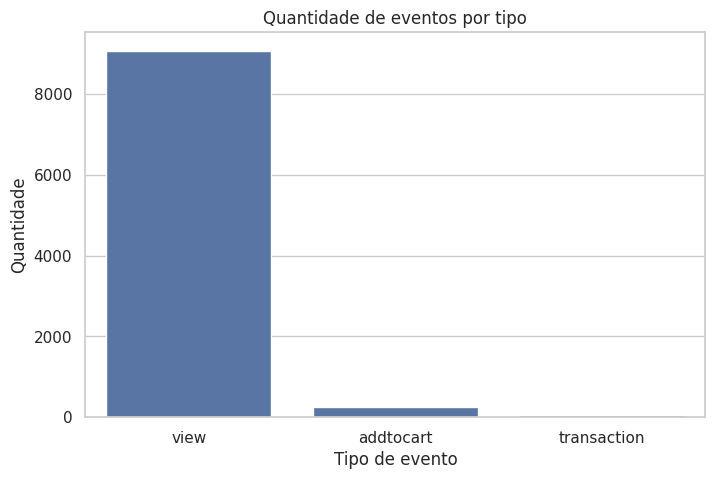

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=events,
    x='event',
    order=events['event'].value_counts().index
)

plt.title('Quantidade de eventos por tipo')
plt.xlabel('Tipo de evento')
plt.ylabel('Quantidade')

plt.show()

### Visitantes / Produto

In [43]:
summary = pd.DataFrame({
    'indicador': [
        'Eventos',
        'Visitantes únicos',
        'Produtos únicos',
        'Transações identificadas'
    ],
    'quantidade': [
        len(events),
        events['visitorid'].nunique(),
        events['itemid'].nunique(),
        events['transactionid'].notna().sum()
    ]
})

display(summary)

,indicador,quantidade
0,Eventos,9385
1,Visitantes únicos,5000
2,Produtos únicos,6610
3,Transações identificadas,46


### Visitantes / Tipo de Evento

In [44]:
visitors_by_event = (
    events.groupby('event')['visitorid']
    .nunique()
    .sort_values(ascending=False)
    .rename('visitantes_unicos')
    .to_frame()
)

display(visitors_by_event)

,visitantes_unicos
event,
view,4991
addtocart,145
transaction,39


### Produtos / Tipo de Interação

In [45]:
products_by_event = (
    events.groupby('event')['itemid']
    .nunique()
    .sort_values(ascending=False)
    .rename('produtos_unicos')
    .to_frame()
)

display(products_by_event)

,produtos_unicos
event,
view,6564
addtocart,225
transaction,46


### Período dos dados

In [46]:
print('Primeiro evento:')
print(events['datetime'].min())

print('\nÚltimo evento:')
print(events['datetime'].max())

Primeiro evento:
2015-05-03 03:02:00.563000

Último evento:
2015-09-18 01:16:53.281000


In [47]:
# Quanto eventos ocorreram por dia
events_by_day = (
    events
    .set_index('datetime')
    .resample('D')
    .size()
    .rename('quantidade_eventos')
)

display(events_by_day.head())

,quantidade_eventos
datetime,
2015-05-03,24
2015-05-04,60
2015-05-05,67
2015-05-06,87
2015-05-07,123


### Gráfico: Eventos ao longo do tempo

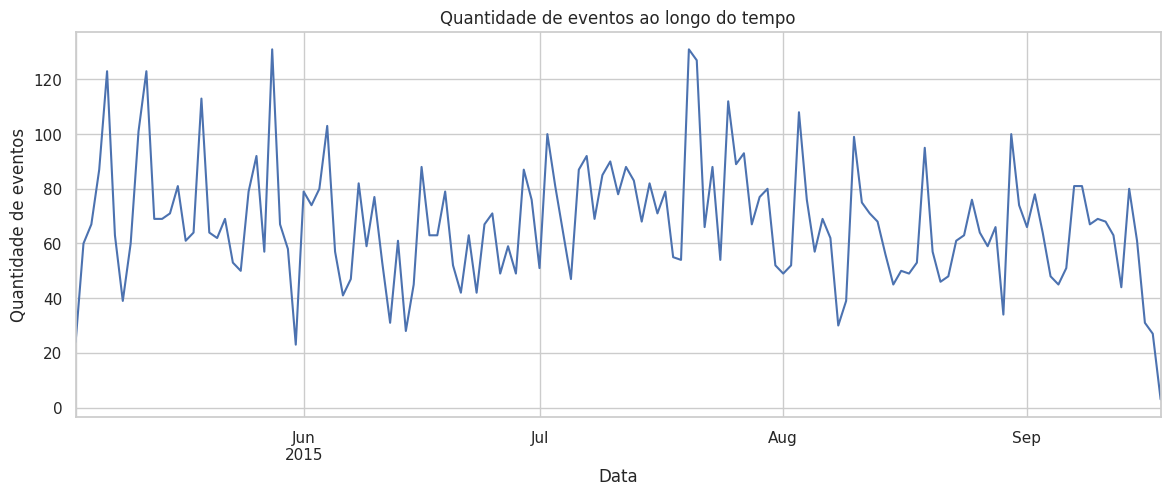

In [48]:
plt.figure(figsize=(14, 5))

events_by_day.plot()

plt.title('Quantidade de eventos ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Quantidade de eventos')

plt.show()

### Separando as transações

In [49]:
transactions = events[
    events['event'] == 'transaction'
].copy()

print('Eventos de compra:', len(transactions))
print('Visitantes que compraram:', transactions['visitorid'].nunique())
print('Produtos comprados:', transactions['itemid'].nunique())

display(transactions.head())

Eventos de compra: 46
Visitantes que compraram: 39
Produtos comprados: 46


,timestamp,visitorid,event,itemid,transactionid,datetime
241,1433440854985,1207981,transaction,350734,8693.0,2015-06-04 18:00:54.985
324,1433446155080,763580,transaction,257115,15026.0,2015-06-04 19:29:15.080
484,1433748335994,766502,transaction,414995,10859.0,2015-06-08 07:25:35.994
488,1433787533953,293600,transaction,55044,3462.0,2015-06-08 18:18:53.953
612,1433976818104,343404,transaction,44220,16824.0,2015-06-10 22:53:38.104


### Produtos mais visualizados

In [50]:
most_viewed = (
    events[events['event'] == 'view']
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename('visualizacoes')
    .to_frame()
)

display(most_viewed)

,visualizacoes
itemid,
153401,33
95489,30
447661,19
212583,18
322920,14
461686,12
187946,11
20407,11
234255,10


### Produtos mais comprados

,compras
itemid,
698,1
18171,1
20407,1
22145,1
36290,1
44220,1
50684,1
55044,1
76426,1


<Figure size 1200x500 with 0 Axes>

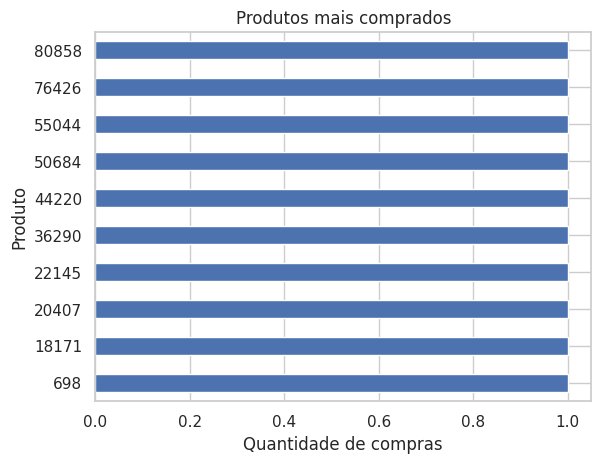

In [51]:
most_purchased = (
    transactions
    .groupby('itemid')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename('compras')
    .to_frame()
)

display(most_purchased)

# Gráfico
plt.figure(figsize=(12, 5))

most_purchased.sort_values('compras').plot(
    kind='barh',
    legend=False
)

plt.title('Produtos mais comprados')
plt.xlabel('Quantidade de compras')
plt.ylabel('Produto')

plt.show()

### Eventos / Visitante

,quantidade_eventos
count,5000.000000
mean,1.877000
std,2.796826
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,55.000000


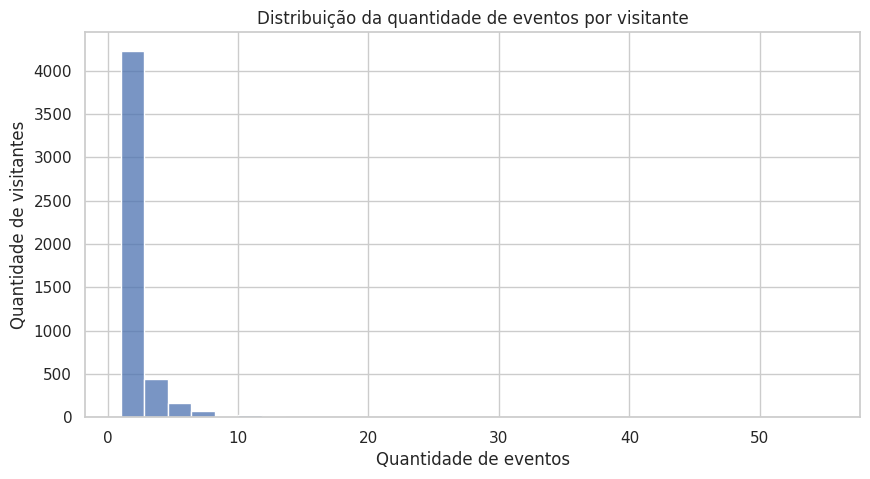

In [52]:
events_per_visitor = (
    events.groupby('visitorid')
    .size()
    .rename('quantidade_eventos')
)

display(events_per_visitor.describe())

plt.figure(figsize=(10, 5))

sns.histplot(
    events_per_visitor,
    bins=30,
    kde=False
)

plt.title('Distribuição da quantidade de eventos por visitante')
plt.xlabel('Quantidade de eventos')
plt.ylabel('Quantidade de visitantes')

plt.show()

### Taxa simples de conversão por produto

In [53]:
views_by_item = (
    events[events['event'] == 'view']
    .groupby('itemid')
    .size()
    .rename('visualizacoes')
)

transactions_by_item = (
    events[events['event'] == 'transaction']
    .groupby('itemid')
    .size()
    .rename('transacoes')
)

item_statistics = pd.concat(
    [views_by_item, transactions_by_item],
    axis=1
).fillna(0)

item_statistics['taxa_conversao'] = (
    item_statistics['transacoes'] /
    item_statistics['visualizacoes'].clip(lower=1)
)

item_statistics = item_statistics.sort_values(
    'taxa_conversao',
    ascending=False
)

display(item_statistics.head(10))

,visualizacoes,transacoes,taxa_conversao
itemid,,,
36290,1.0,1.0,1.0
85377,1.0,1.0,1.0
257115,1.0,1.0,1.0
108924,1.0,1.0,1.0
361982,1.0,1.0,1.0
415562,1.0,1.0,1.0
408504,1.0,1.0,1.0
365758,0.0,1.0,1.0
144599,0.0,1.0,1.0


### Salvando os resultados

In [54]:
event_counts.to_csv(
    '/content/event_counts.csv',
    index=False
)

summary.to_csv(
    '/content/dataset_summary.csv',
    index=False
)

item_statistics.to_csv(
    '/content/item_statistics.csv'
)

print('Tabelas exploratórias salvas em /content.')

Tabelas exploratórias salvas em /content.


## Etapa 2: Construindo o grafo de interações

Nesta etapa será construído um grafo bipartido entre visitantes e produtos.

Cada aresta representa uma interação de um visitante com um produto.
Os diferentes tipos de evento receberão pesos diferentes:
- visualização;
- adição ao carrinho;
- transação.

In [55]:
# Importando o NetworkX
import networkx as nx

print('NetworkX carregado com sucesso.')

# Preparando os eventos
interactions = events[
    ['visitorid', 'itemid', 'event', 'datetime']
].copy()

interactions.head()

# Verificando se existem valores ausentes
print('Valores ausentes:')
display(interactions.isna().sum().to_frame('quantidade'))

# Removendo linhas sem visitante ou sem produto
interactions = interactions.dropna(
    subset=['visitorid', 'itemid']
).copy()

print('Eventos após remoção de valores ausentes:', len(interactions))

NetworkX carregado com sucesso.
Valores ausentes:


,quantidade
visitorid,0
itemid,0
event,0
datetime,0


Eventos após remoção de valores ausentes: 9385


### Atribuindo pesos aos eventos

| Evento      | Peso |
| ----------- | ---- |
| view        | 1    |
| addtocart   | 3    |
| transaction | 5    |


In [56]:
event_weights = {
    'view': 1.0,
    'addtocart': 3.0,
    'transaction': 5.0
}

interactions['edge_weight'] = (
    interactions['event']
    .map(event_weights)
    .fillna(0)
)

display(
    interactions[
        ['visitorid', 'itemid', 'event', 'edge_weight']
    ].head(10)
)

# Verificando
interactions['edge_weight'].value_counts()

,visitorid,itemid,event,edge_weight
0,1134473,396045,view,1.0
1,1314862,344224,view,1.0
2,467124,396318,view,1.0
3,1121229,370889,view,1.0
4,39027,26210,view,1.0
5,39027,190172,view,1.0
6,1246312,104261,view,1.0
7,595804,162525,view,1.0
8,1342843,55124,view,1.0
9,1125119,105246,view,1.0


,count
edge_weight,
1.0,9076
3.0,263
5.0,46


### Agregando interações repetidas

In [57]:
edge_data = (
    interactions
    .groupby(['visitorid', 'itemid'], as_index=False)
    .agg(
        weight=('edge_weight', 'sum'),
        interaction_count=('event', 'size'),
        last_interaction=('datetime', 'max')
    )
)

edge_data.head()

# Verificando
print('Relações únicas visitante-produto:', len(edge_data))
print('Visitantes:', edge_data['visitorid'].nunique())
print('Produtos:', edge_data['itemid'].nunique())

Relações únicas visitante-produto: 7390
Visitantes: 5000
Produtos: 6610


### Criando identificadores para os nós

In [58]:
edge_data['visitor_node'] = (
    'visitor_' + edge_data['visitorid'].astype(str)
)

edge_data['item_node'] = (
    'item_' + edge_data['itemid'].astype(str)
)

edge_data.head()

,visitorid,itemid,weight,interaction_count,last_interaction,visitor_node,item_node
0,340,21348,1.0,1,2015-08-21 20:20:37.419,visitor_340,item_21348
1,519,464767,2.0,2,2015-07-11 16:42:59.228,visitor_519,item_464767
2,918,97307,2.0,2,2015-07-30 00:31:27.615,visitor_918,item_97307
3,918,222888,6.0,2,2015-07-29 20:23:23.569,visitor_918,item_222888
4,956,151444,1.0,1,2015-09-14 03:36:57.925,visitor_956,item_151444


### Criando o grafo

In [59]:
G = nx.Graph()

# Adiciona nós de visitantes
visitor_nodes = edge_data['visitor_node'].unique()

G.add_nodes_from(
    visitor_nodes,
    bipartite='visitor',
    node_type='visitor'
)

# Adiciona nós de produtos
item_nodes = edge_data['item_node'].unique()

G.add_nodes_from(
    item_nodes,
    bipartite='item',
    node_type='item'
)

# Adiciona arestas visitante-produto
for row in edge_data.itertuples(index=False):
    G.add_edge(
        row.visitor_node,
        row.item_node,
        weight=float(row.weight),
        interaction_count=int(row.interaction_count),
        last_interaction=row.last_interaction
    )

print('Grafo criado com sucesso.')

# Verificando
print('Quantidade de nós:', G.number_of_nodes())
print('Quantidade de arestas:', G.number_of_edges())

## Contando cada tipo de nó
visitor_count = sum(
    1 for _, data in G.nodes(data=True)
    if data.get('node_type') == 'visitor'
)

item_count = sum(
    1 for _, data in G.nodes(data=True)
    if data.get('node_type') == 'item'
)

print('Nós visitantes:', visitor_count)
print('Nós produtos:', item_count)

## Verificando se o grafo é bipartido
print('É um grafo bipartido?', nx.is_bipartite(G))

Grafo criado com sucesso.
Quantidade de nós: 11610
Quantidade de arestas: 7390
Nós visitantes: 5000
Nós produtos: 6610
É um grafo bipartido? True


### Visualizando as primeiras arestas

In [60]:
edges_preview = list(G.edges(data=True))[:10]

for source, target, attributes in edges_preview:
    print(source, '--', target, attributes)

visitor_340 -- item_21348 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-08-21 20:20:37.419000')}
visitor_519 -- item_464767 {'weight': 2.0, 'interaction_count': 2, 'last_interaction': Timestamp('2015-07-11 16:42:59.228000')}
visitor_918 -- item_97307 {'weight': 2.0, 'interaction_count': 2, 'last_interaction': Timestamp('2015-07-30 00:31:27.615000')}
visitor_918 -- item_222888 {'weight': 6.0, 'interaction_count': 2, 'last_interaction': Timestamp('2015-07-29 20:23:23.569000')}
visitor_956 -- item_151444 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-09-14 03:36:57.925000')}
visitor_1041 -- item_313275 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-09-13 10:35:47.976000')}
visitor_1618 -- item_140156 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-08-11 00:00:34.830000')}
visitor_1766 -- item_448461 {'weight': 1.0, 'interaction_count': 1, 'last_interaction': Timestamp('2015-

### Calculando o grau ponderado dos produtos

In [61]:
item_degree = {}

for item_node in item_nodes:
    item_degree[item_node] = G.degree(
        item_node,
        weight='weight'
    )

item_degree_df = (
    pd.DataFrame.from_dict(
        item_degree,
        orient='index',
        columns=['weighted_degree']
    )
    .rename_axis('item_node')
    .reset_index()
)

item_degree_df.head()

,item_node,weighted_degree
0,item_21348,1.0
1,item_464767,4.0
2,item_97307,4.0
3,item_222888,13.0
4,item_151444,2.0


### Calculando o PageRank

In [62]:
pagerank_scores = nx.pagerank(
    G,
    alpha=0.85,
    weight='weight'
)

print('PageRank calculado.')

PageRank calculado.


### Tabela de métricas dos produtos

In [63]:
item_metrics = pd.DataFrame({
    'item_node': item_nodes
})

item_metrics['itemid'] = (
    item_metrics['item_node']
    .str.replace('item_', '', regex=False)
    .astype(int)
)

item_metrics['weighted_degree'] = (
    item_metrics['item_node']
    .map(item_degree)
)

item_metrics['pagerank'] = (
    item_metrics['item_node']
    .map(pagerank_scores)
)

item_metrics = item_metrics.sort_values(
    'pagerank',
    ascending=False
).reset_index(drop=True)

display(item_metrics.head(10))

,item_node,itemid,weighted_degree,pagerank
0,item_187946,187946,11.0,0.000432
1,item_20407,20407,19.0,0.000321
2,item_5411,5411,10.0,0.000319
3,item_370653,370653,7.0,0.000311
4,item_434782,434782,8.0,0.000289
5,item_354233,354233,7.0,0.000274
6,item_461686,461686,18.0,0.000268
7,item_212583,212583,29.0,0.000260
8,item_234255,234255,10.0,0.000259
9,item_29196,29196,11.0,0.000250


### Produtos mais importantes pelo PageRank

In [64]:
top_pagerank_items = item_metrics.head(10)

display(top_pagerank_items)

# Ordenação pelo grau ponderado
top_degree_items = (
    item_metrics
    .sort_values('weighted_degree', ascending=False)
    .head(10)
)

display(top_degree_items)

,item_node,itemid,weighted_degree,pagerank
0,item_187946,187946,11.0,0.000432
1,item_20407,20407,19.0,0.000321
2,item_5411,5411,10.0,0.000319
3,item_370653,370653,7.0,0.000311
4,item_434782,434782,8.0,0.000289
5,item_354233,354233,7.0,0.000274
6,item_461686,461686,18.0,0.000268
7,item_212583,212583,29.0,0.000260
8,item_234255,234255,10.0,0.000259
9,item_29196,29196,11.0,0.000250


,item_node,itemid,weighted_degree,pagerank
27,item_95489,95489,39.0,0.000173
25,item_153401,153401,36.0,0.000181
7,item_212583,212583,29.0,0.000260
11,item_90931,90931,26.0,0.000240
1,item_20407,20407,19.0,0.000321
14,item_447661,447661,19.0,0.000221
140,item_442747,442747,18.0,0.000130
6,item_461686,461686,18.0,0.000268
29,item_80858,80858,15.0,0.000172
12,item_190534,190534,15.0,0.000239


### Comparando PageRank e Grau

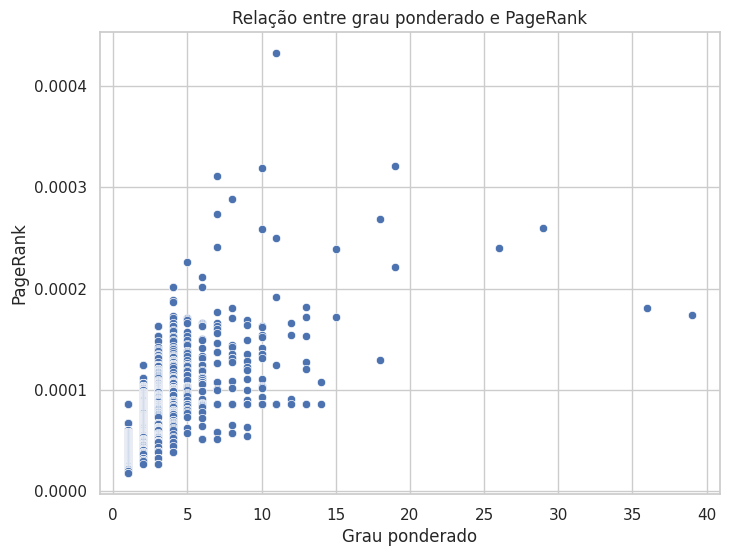

,weighted_degree,pagerank
weighted_degree,1.000000,0.462624
pagerank,0.462624,1.000000


In [65]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=item_metrics,
    x='weighted_degree',
    y='pagerank'
)

plt.title('Relação entre grau ponderado e PageRank')
plt.xlabel('Grau ponderado')
plt.ylabel('PageRank')

plt.show()

# Calculando a correlação
correlation = item_metrics[
    ['weighted_degree', 'pagerank']
].corr()

display(correlation)

### Visualizando um subgrafo

In [77]:
# Verificando quantos visitantes cada produto possui
display(
    products_per_visitor
    .value_counts()
    .sort_index()
    .rename_axis('quantidade_produtos')
    .to_frame('quantidade_visitantes')
)

,quantidade_visitantes
quantidade_produtos,
1,3932
2,605
3,222
4,91
5,43
6,40
7,20
8,9
9,7


Visitante selecionado: visitor_954684
Quantidade de produtos: 49
Produtos associados:
item_6
item_997
item_13837
item_26514
item_34269
item_47353
item_47889
item_56944
item_62252
item_74885
item_79057
item_99298
item_104858
item_156152
item_160302
item_181469
item_184206
item_195360
item_233925
item_242380
item_256271
item_264392
item_266999
item_267670
item_272144
item_274699
item_287572
item_295168
item_318106
item_320785
item_323536
item_336552
item_345755
item_350647
item_360358
item_363828
item_364230
item_365447
item_383715
item_393252
item_397335
item_411580
item_415023
item_424932
item_426026
item_432868
item_440450
item_444119
item_453546
Nós no subgrafo: 50
Arestas no subgrafo: 49


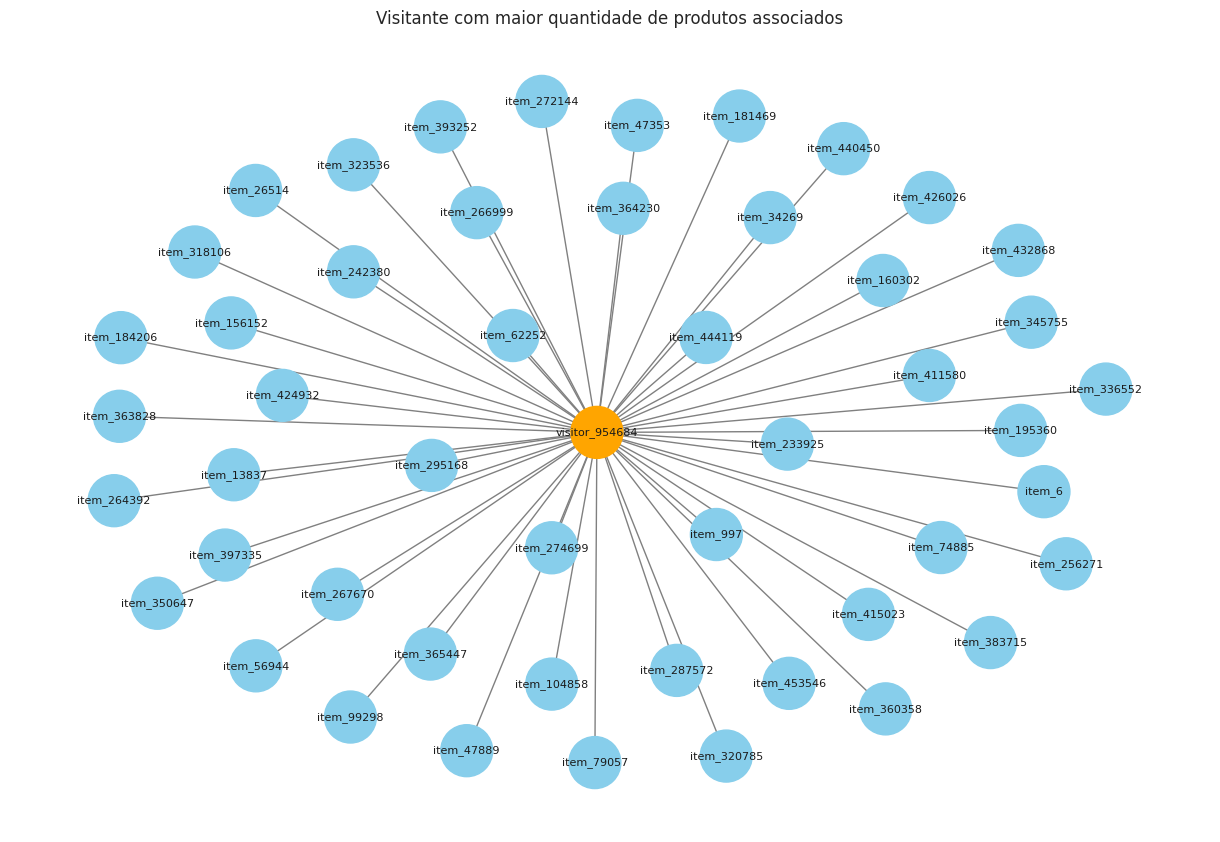

In [76]:
# Selecionando aquele que visitou mais produtos
products_per_visitor = (
    edge_data
    .groupby('visitor_node')['item_node']
    .nunique()
    .sort_values(ascending=False)
)

selected_visitor = products_per_visitor.idxmax()

print('Visitante selecionado:', selected_visitor)
print(
    'Quantidade de produtos:',
    products_per_visitor.loc[selected_visitor]
)

selected_products = list(
    G.neighbors(selected_visitor)
)

print('Produtos associados:')
for product in selected_products:
    print(product)

small_nodes = [selected_visitor] + selected_products

G_small = G.subgraph(small_nodes).copy()

print('Nós no subgrafo:', G_small.number_of_nodes())
print('Arestas no subgrafo:', G_small.number_of_edges())

plt.figure(figsize=(12, 8))

positions = nx.spring_layout(
    G_small,
    seed=42
)

node_colors = []

for node in G_small.nodes():
    if G_small.nodes[node].get('node_type') == 'visitor':
        node_colors.append('orange')
    else:
        node_colors.append('skyblue')

nx.draw(
    G_small,
    positions,
    with_labels=True,
    node_color=node_colors,
    node_size=1400,
    font_size=8,
    edge_color='gray'
)

plt.title('Visitante com maior quantidade de produtos associados')
plt.show()

In [83]:
# Limita a visualização aos primeiros produtos do visitante selecionado
products_for_visualization = selected_products[:10]

# Encontra outros visitantes conectados a esses produtos
related_visitors = set()

for product in products_for_visualization:
    related_visitors.update(
        neighbor
        for neighbor in G.neighbors(product)
        if G.nodes[neighbor].get('node_type') == 'visitor'
    )

# Limita a quantidade de visitantes para evitar um gráfico muito grande
related_visitors = list(related_visitors)[:10]

# Cria os nós do subgrafo expandido
expanded_nodes = (
    [selected_visitor]
    + related_visitors
    + products_for_visualization
)

G_expanded = G.subgraph(expanded_nodes).copy()

print('Visitantes no subgrafo:', len(related_visitors) + 1)
print('Produtos no subgrafo:', len(products_for_visualization))
print('Arestas:', G_expanded.number_of_edges())

Visitantes no subgrafo: 3
Produtos no subgrafo: 10
Arestas: 11


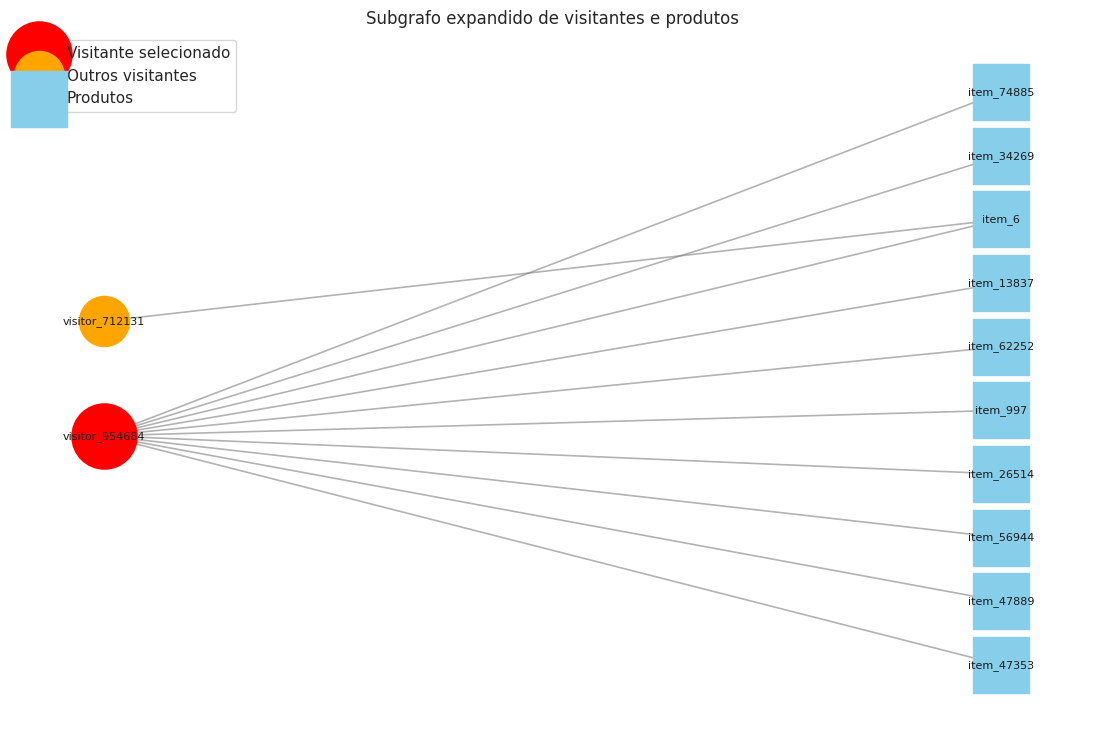

In [84]:
# Desenha o grafo
plt.figure(figsize=(14, 9))

visitor_nodes_expanded = [
    node for node in G_expanded.nodes()
    if G_expanded.nodes[node].get('node_type') == 'visitor'
]

product_nodes_expanded = [
    node for node in G_expanded.nodes()
    if G_expanded.nodes[node].get('node_type') == 'item'
]

# Cria posições manuais
positions_expanded = {}

visitor_y = np.linspace(
    -len(visitor_nodes_expanded),
    len(visitor_nodes_expanded),
    len(visitor_nodes_expanded)
)

product_y = np.linspace(
    -len(product_nodes_expanded),
    len(product_nodes_expanded),
    len(product_nodes_expanded)
)

for node, y in zip(visitor_nodes_expanded, visitor_y):
    positions_expanded[node] = (0, y)

for node, y in zip(product_nodes_expanded, product_y):
    positions_expanded[node] = (1, y)

# Desenha arestas
nx.draw_networkx_edges(
    G_expanded,
    positions_expanded,
    edge_color='gray',
    alpha=0.6,
    width=1.2
)

# Destaca o visitante escolhido
nx.draw_networkx_nodes(
    G_expanded,
    positions_expanded,
    nodelist=[selected_visitor],
    node_color='red',
    node_size=2200,
    node_shape='o',
    label='Visitante selecionado'
)

# Outros visitantes
other_visitors = [
    node for node in visitor_nodes_expanded
    if node != selected_visitor
]

nx.draw_networkx_nodes(
    G_expanded,
    positions_expanded,
    nodelist=other_visitors,
    node_color='orange',
    node_size=1300,
    node_shape='o',
    label='Outros visitantes'
)

# Produtos
nx.draw_networkx_nodes(
    G_expanded,
    positions_expanded,
    nodelist=product_nodes_expanded,
    node_color='skyblue',
    node_size=1600,
    node_shape='s',
    label='Produtos'
)

# Rótulos
nx.draw_networkx_labels(
    G_expanded,
    positions_expanded,
    font_size=8
)

plt.title(
    'Subgrafo expandido de visitantes e produtos'
)

plt.legend()
plt.axis('off')
plt.show()

### Salvando as métricas do grafo

In [78]:
item_metrics.to_csv(
    '/content/item_graph_metrics.csv',
    index=False
)

edge_data.to_csv(
    '/content/graph_edges.csv',
    index=False
)

print('Métricas e arestas salvas no ambiente do Colab.')

Métricas e arestas salvas no ambiente do Colab.


## Etapa 3: Construindo a baseline de recomendação

O baseline recomenda produtos com base na coocorrência no histórico dos visitantes.

Dois produtos são relacionados quando foram associados ao mesmo visitante.

Por exemplo:

*   Visitante A interagiu com Produto 1 e Produto 2
*   Visitante B interagiu com Produto 1 e Produto 3

Então, podem ser estabelecidas as relações:

*   Produto 1 ── Produto 2
*   Produto 1 ── Produto 3

Se um novo visitante interagiu com o Produto 1, o baseline pode recomendar:

*   Produto 2
*   Produto 3

In [85]:
# Imports
from itertools import combinations

print('Biblioteca carregada.')

Biblioteca carregada.


### Construindo o grafo produto-produto

In [86]:
item_graph = nx.Graph()

# Percorre todos os visitantes do grafo original
for visitor in visitor_nodes:
    visitor_products = list(G.neighbors(visitor))

    # Visitantes com apenas um produto não criam relação entre produtos
    if len(visitor_products) < 2:
        continue

    # Cria pares de produtos associados ao mesmo visitante
    for item_a, item_b in combinations(
        sorted(visitor_products),
        2
    ):
        # Peso da nova relação
        shared_weight = 1.0

        if item_graph.has_edge(item_a, item_b):
            item_graph[item_a][item_b]['weight'] += shared_weight
        else:
            item_graph.add_edge(
                item_a,
                item_b,
                weight=shared_weight
            )

print('Grafo produto-produto criado.')
print('Produtos:', item_graph.number_of_nodes())
print('Relações:', item_graph.number_of_edges())

Grafo produto-produto criado.
Produtos: 3219
Relações: 8335


### Visualizando as relações mais fortes

In [87]:
item_edges = pd.DataFrame(
    [
        {
            'item_a': source,
            'item_b': target,
            'weight': attributes['weight']
        }
        for source, target, attributes
        in item_graph.edges(data=True)
    ]
)

item_edges = item_edges.sort_values(
    'weight',
    ascending=False
)

display(item_edges.head(20))

,item_a,item_b,weight
3259,item_234255,item_355994,3.0
3266,item_234255,item_460188,3.0
823,item_218794,item_461686,3.0
386,item_241555,item_325310,2.0
814,item_171878,item_218794,2.0
7584,item_302311,item_357474,2.0
1604,item_437927,item_76295,2.0
1723,item_195360,item_430317,2.0
5256,item_91105,item_274798,2.0
5258,item_91105,item_302311,2.0


### Criando a função de recomendação

In [88]:
def recommend_baseline(
    visitor_node,
    graph,
    item_graph,
    top_k=10
):
    """
    Recomenda produtos para um visitante usando
    relações de coocorrência entre produtos.
    """

    # Produtos já conhecidos pelo visitante
    history = set(graph.neighbors(visitor_node))

    candidate_scores = {}

    # Percorre os produtos do histórico
    for history_item in history:

        # Se o produto não estiver no grafo produto-produto,
        # não há relações para explorar
        if history_item not in item_graph:
            continue

        # Produtos relacionados ao item do histórico
        for candidate in item_graph.neighbors(history_item):

            # Não recomenda produtos que o visitante já conhece
            if candidate in history:
                continue

            relation_weight = item_graph[
                history_item
            ][candidate]['weight']

            candidate_scores[candidate] = (
                candidate_scores.get(candidate, 0)
                + relation_weight
            )

    if not candidate_scores:
        return pd.DataFrame(
            columns=[
                'item_node',
                'recommendation_score'
            ]
        )

    recommendations = (
        pd.DataFrame(
            [
                {
                    'item_node': item,
                    'recommendation_score': score
                }
                for item, score
                in candidate_scores.items()
            ]
        )
        .sort_values(
            'recommendation_score',
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )

    return recommendations

### Testando com o visitante selecionado

In [89]:
baseline_recommendations = recommend_baseline(
    visitor_node=selected_visitor,
    graph=G,
    item_graph=item_graph,
    top_k=10
)

display(baseline_recommendations)

# Usando um visitante com pelo menos 3 produtos
eligible_visitors = products_per_visitor[
    products_per_visitor >= 3
]

selected_visitor = eligible_visitors.index[0]

baseline_recommendations = recommend_baseline(
    visitor_node=selected_visitor,
    graph=G,
    item_graph=item_graph,
    top_k=10
)

print('Visitante:', selected_visitor)
display(baseline_recommendations)

,item_node,recommendation_score
0,item_430317,2.0
1,item_272152,1.0
2,item_344010,1.0
3,item_299751,1.0
4,item_385475,1.0
5,item_390036,1.0
6,item_178147,1.0
7,item_404056,1.0
8,item_224060,1.0
9,item_258012,1.0


Visitante: visitor_954684


,item_node,recommendation_score
0,item_430317,2.0
1,item_272152,1.0
2,item_344010,1.0
3,item_299751,1.0
4,item_385475,1.0
5,item_390036,1.0
6,item_178147,1.0
7,item_404056,1.0
8,item_224060,1.0
9,item_258012,1.0


### Mostrando os produtos do histórico

In [90]:
visitor_history = list(
    G.neighbors(selected_visitor)
)

print('Produtos já conhecidos pelo visitante:')

for item in visitor_history:
    print(item)

# Comparando as recomendações
print('Produtos recomendados pelo baseline:')

for item in baseline_recommendations['item_node']:
    print(item)

Produtos já conhecidos pelo visitante:
item_6
item_997
item_13837
item_26514
item_34269
item_47353
item_47889
item_56944
item_62252
item_74885
item_79057
item_99298
item_104858
item_156152
item_160302
item_181469
item_184206
item_195360
item_233925
item_242380
item_256271
item_264392
item_266999
item_267670
item_272144
item_274699
item_287572
item_295168
item_318106
item_320785
item_323536
item_336552
item_345755
item_350647
item_360358
item_363828
item_364230
item_365447
item_383715
item_393252
item_397335
item_411580
item_415023
item_424932
item_426026
item_432868
item_440450
item_444119
item_453546
Produtos recomendados pelo baseline:
item_430317
item_272152
item_344010
item_299751
item_385475
item_390036
item_178147
item_404056
item_224060
item_258012


### Adicionando as métricas do grafo

In [91]:
# Convertendo os IDs para números
baseline_recommendations['itemid'] = (
    baseline_recommendations['item_node']
    .str.replace('item_', '', regex=False)
    .astype(int)
)

display(baseline_recommendations)

# Acrescentando o PageRank e o grau ponderado aos produtos recomendados
baseline_recommendations['pagerank'] = (
    baseline_recommendations['item_node']
    .map(pagerank_scores)
    .fillna(0)
)

baseline_recommendations['weighted_degree'] = (
    baseline_recommendations['item_node']
    .map(item_degree)
    .fillna(0)
)

display(baseline_recommendations)

,item_node,recommendation_score,itemid
0,item_430317,2.0,430317
1,item_272152,1.0,272152
2,item_344010,1.0,344010
3,item_299751,1.0,299751
4,item_385475,1.0,385475
5,item_390036,1.0,390036
6,item_178147,1.0,178147
7,item_404056,1.0,404056
8,item_224060,1.0,224060
9,item_258012,1.0,258012


,item_node,recommendation_score,itemid,pagerank,weighted_degree
0,item_430317,2.0,430317,0.000069,2.0
1,item_272152,1.0,272152,0.000052,1.0
2,item_344010,1.0,344010,0.000123,5.0
3,item_299751,1.0,299751,0.000041,1.0
4,item_385475,1.0,385475,0.000069,2.0
5,item_390036,1.0,390036,0.000081,2.0
6,item_178147,1.0,178147,0.000041,1.0
7,item_404056,1.0,404056,0.000081,2.0
8,item_224060,1.0,224060,0.000041,1.0
9,item_258012,1.0,258012,0.000094,3.0


### Visualizando o ranking do baseline

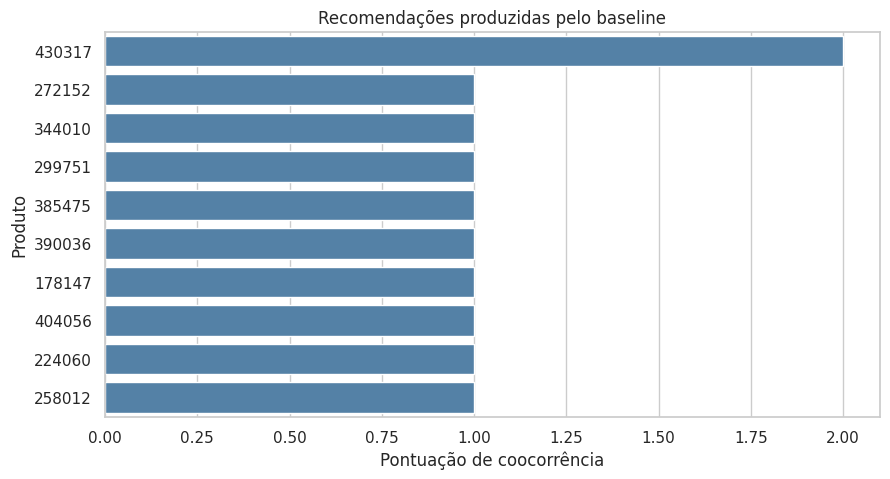

In [92]:
plt.figure(figsize=(10, 5))

plot_data = baseline_recommendations.copy()

plot_data['label'] = (
    plot_data['item_node']
    .str.replace('item_', '', regex=False)
)

sns.barplot(
    data=plot_data,
    x='recommendation_score',
    y='label',
    color='steelblue'
)

plt.title('Recomendações produzidas pelo baseline')
plt.xlabel('Pontuação de coocorrência')
plt.ylabel('Produto')

plt.show()

O baseline:

*   olha o histórico do visitante;
*   encontra produtos relacionados;
*   conta quantas vezes cada candidato aparece nas relações do grafo;
*   ordena por essa contagem.


### Etapa 4: Preparando a matriz de decisão TOPSIS

Nesta etapa serão calculados os critérios dos produtos recomendados
pelo baseline.

Os critérios utilizados inicialmente serão:

*   força da relação entre produtos;
*   PageRank;
*   grau ponderado;
*   taxa de conversão;
*   recência das interações.

#### Critérios TOPSIS
| Critério                     | Origem          | Tipo      |
| ---------------------------- | --------------- | --------- |
| Pontuação de coocorrência    | Baseline        | Benefício |
| PageRank                     | Grafo           | Benefício |
| Grau ponderado               | Grafo           | Benefício |
| Recência                     | Eventos         | Benefício |
| Taxa de conversão            | Eventos         | Benefício |

In [93]:
# Copiando os candidatos do baseline
topsis_candidates = baseline_recommendations.copy()

display(topsis_candidates)

# Verificando as colunas
print(topsis_candidates.columns.tolist())

,item_node,recommendation_score,itemid,pagerank,weighted_degree
0,item_430317,2.0,430317,0.000069,2.0
1,item_272152,1.0,272152,0.000052,1.0
2,item_344010,1.0,344010,0.000123,5.0
3,item_299751,1.0,299751,0.000041,1.0
4,item_385475,1.0,385475,0.000069,2.0
5,item_390036,1.0,390036,0.000081,2.0
6,item_178147,1.0,178147,0.000041,1.0
7,item_404056,1.0,404056,0.000081,2.0
8,item_224060,1.0,224060,0.000041,1.0
9,item_258012,1.0,258012,0.000094,3.0


['item_node', 'recommendation_score', 'itemid', 'pagerank', 'weighted_degree']


### Calculando as estatísticas para cada produto

In [94]:
item_behavior = events.copy()

item_behavior['item_node'] = (
    'item_' + item_behavior['itemid'].astype(str)
)

item_behavior.head()

,timestamp,visitorid,event,itemid,transactionid,datetime,item_node
0,1433193132535,1134473,view,396045,NaN,2015-06-01 21:12:12.535,item_396045
1,1433194696771,1314862,view,344224,NaN,2015-06-01 21:38:16.771,item_344224
2,1433220848630,467124,view,396318,NaN,2015-06-02 04:54:08.630,item_396318
3,1433218109710,1121229,view,370889,NaN,2015-06-02 04:08:29.710,item_370889
4,1433178802896,39027,view,26210,NaN,2015-06-01 17:13:22.896,item_26210


### Calculando visualizações, carrinhos e transações

In [95]:
views_by_item = (
    item_behavior[item_behavior['event'] == 'view']
    .groupby('item_node')
    .size()
    .rename('views')
)

carts_by_item = (
    item_behavior[item_behavior['event'] == 'addtocart']
    .groupby('item_node')
    .size()
    .rename('addtocart')
)

transactions_by_item = (
    item_behavior[item_behavior['event'] == 'transaction']
    .groupby('item_node')
    .size()
    .rename('transactions')
)

item_behavior_stats = pd.concat(
    [
        views_by_item,
        carts_by_item,
        transactions_by_item
    ],
    axis=1
).fillna(0)

display(item_behavior_stats.head())

,views,addtocart,transactions
item_node,,,
item_100004,1.0,0.0,0.0
item_100049,1.0,0.0,0.0
item_100150,2.0,0.0,0.0
item_100172,1.0,0.0,0.0
item_100296,3.0,0.0,0.0


### Calculando a taxa de conversão

In [96]:
item_behavior_stats['conversion_rate'] = (
    item_behavior_stats['transactions'] /
    item_behavior_stats['views'].clip(lower=1)
)

display(
    item_behavior_stats
    .sort_values('conversion_rate', ascending=False)
    .head(10)
)

,views,addtocart,transactions,conversion_rate
item_node,,,,
item_365758,0.0,1.0,1.0,1.0
item_361982,1.0,1.0,1.0,1.0
item_122604,1.0,1.0,1.0,1.0
item_257115,1.0,1.0,1.0,1.0
item_415562,1.0,1.0,1.0,1.0
item_144599,0.0,1.0,1.0,1.0
item_225572,0.0,1.0,1.0,1.0
item_250375,0.0,1.0,1.0,1.0
item_85377,1.0,1.0,1.0,1.0


### Calculando a recência

In [97]:
last_interaction = (
    item_behavior
    .groupby('item_node')['datetime']
    .max()
    .rename('last_interaction')
)

item_behavior_stats = item_behavior_stats.join(
    last_interaction
)

reference_date = item_behavior['datetime'].max()

item_behavior_stats['days_since_last_interaction'] = (
    reference_date -
    item_behavior_stats['last_interaction']
).dt.total_seconds() / (24 * 60 * 60)

In [98]:
# Transformando a distância em uma pontuação de recência
item_behavior_stats['recency_score'] = (
    1 /
    (1 + item_behavior_stats['days_since_last_interaction'])
)

display(
    item_behavior_stats[
        [
            'last_interaction',
            'days_since_last_interaction',
            'recency_score'
        ]
    ].head()
)

,last_interaction,days_since_last_interaction,recency_score
item_node,,,
item_100004,2015-05-08 00:18:46.255,133.040359,0.007460
item_100049,2015-08-06 04:21:59.655,42.871454,0.022794
item_100150,2015-06-20 21:04:29.083,89.175280,0.011090
item_100172,2015-07-02 11:52:57.055,77.558290,0.012729
item_100296,2015-07-17 01:29:56.413,62.990936,0.015627


### Juntando os critérios

In [99]:
topsis_matrix = topsis_candidates[
    [
        'item_node',
        'recommendation_score',
        'pagerank',
        'weighted_degree'
    ]
].copy()

topsis_matrix = topsis_matrix.merge(
    item_behavior_stats[
        [
            'conversion_rate',
            'recency_score'
        ]
    ],
    left_on='item_node',
    right_index=True,
    how='left'
)

topsis_matrix = topsis_matrix.fillna(0)

display(topsis_matrix)

,item_node,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
0,item_430317,2.0,0.000069,2.0,0.0,0.015806
1,item_272152,1.0,0.000052,1.0,0.0,0.010710
2,item_344010,1.0,0.000123,5.0,0.0,0.185140
3,item_299751,1.0,0.000041,1.0,0.0,0.025035
4,item_385475,1.0,0.000069,2.0,0.0,0.025038
5,item_390036,1.0,0.000081,2.0,0.0,0.239037
6,item_178147,1.0,0.000041,1.0,0.0,0.010060
7,item_404056,1.0,0.000081,2.0,0.0,0.043132
8,item_224060,1.0,0.000041,1.0,0.0,0.010060
9,item_258012,1.0,0.000094,3.0,0.0,0.016901


### Verificando a matriz de decisão

In [100]:
criteria = [
    'recommendation_score',
    'pagerank',
    'weighted_degree',
    'conversion_rate',
    'recency_score'
]

decision_matrix = topsis_matrix[criteria].astype(float)

display(decision_matrix)

,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
0,2.0,0.000069,2.0,0.0,0.015806
1,1.0,0.000052,1.0,0.0,0.010710
2,1.0,0.000123,5.0,0.0,0.185140
3,1.0,0.000041,1.0,0.0,0.025035
4,1.0,0.000069,2.0,0.0,0.025038
5,1.0,0.000081,2.0,0.0,0.239037
6,1.0,0.000041,1.0,0.0,0.010060
7,1.0,0.000081,2.0,0.0,0.043132
8,1.0,0.000041,1.0,0.0,0.010060
9,1.0,0.000094,3.0,0.0,0.016901


### Definindo os pesos

In [101]:
weights = {
    'recommendation_score': 0.20,
    'pagerank': 0.20,
    'weighted_degree': 0.20,
    'conversion_rate': 0.20,
    'recency_score': 0.20
}

print('Soma dos pesos:', sum(weights.values()))

Soma dos pesos: 1.0


### Normalizando a matriz

In [102]:
matrix_values = decision_matrix.to_numpy()

denominators = np.sqrt(
    (matrix_values ** 2).sum(axis=0)
)

# Evita divisão por zero
denominators[denominators == 0] = 1

normalized_matrix = (
    matrix_values / denominators
)

normalized_df = pd.DataFrame(
    normalized_matrix,
    columns=criteria,
    index=topsis_matrix['item_node']
)

display(normalized_df)

,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
item_node,,,,,
item_430317,0.55470,0.296838,0.272166,0.0,0.051178
item_272152,0.27735,0.224668,0.136083,0.0,0.034679
item_344010,0.27735,0.527968,0.680414,0.0,0.599470
item_299751,0.27735,0.175108,0.136083,0.0,0.081061
item_385475,0.27735,0.293835,0.272166,0.0,0.081071
item_390036,0.27735,0.348134,0.272166,0.0,0.773983
item_178147,0.27735,0.176725,0.136083,0.0,0.032574
item_404056,0.27735,0.348134,0.272166,0.0,0.139658
item_224060,0.27735,0.176725,0.136083,0.0,0.032574


### Aplicando os pesos

In [103]:
weighted_matrix = normalized_df.copy()

for criterion in criteria:
    weighted_matrix[criterion] = (
        weighted_matrix[criterion] *
        weights[criterion]
    )

display(weighted_matrix)

,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score
item_node,,,,,
item_430317,0.11094,0.059368,0.054433,0.0,0.010236
item_272152,0.05547,0.044934,0.027217,0.0,0.006936
item_344010,0.05547,0.105594,0.136083,0.0,0.119894
item_299751,0.05547,0.035022,0.027217,0.0,0.016212
item_385475,0.05547,0.058767,0.054433,0.0,0.016214
item_390036,0.05547,0.069627,0.054433,0.0,0.154797
item_178147,0.05547,0.035345,0.027217,0.0,0.006515
item_404056,0.05547,0.069627,0.054433,0.0,0.027932
item_224060,0.05547,0.035345,0.027217,0.0,0.006515


### Calculando as soluções ideais

In [104]:
positive_ideal = weighted_matrix.max(axis=0)
negative_ideal = weighted_matrix.min(axis=0)

print('Solução ideal positiva:')
display(positive_ideal.to_frame('valor'))

print('Solução ideal negativa:')
display(negative_ideal.to_frame('valor'))

Solução ideal positiva:


,valor
recommendation_score,0.110940
pagerank,0.105594
weighted_degree,0.136083
conversion_rate,0.000000
recency_score,0.154797


Solução ideal negativa:


,valor
recommendation_score,0.055470
pagerank,0.035022
weighted_degree,0.027217
conversion_rate,0.000000
recency_score,0.006515


### Calculando as distâncias

In [105]:
distance_positive = np.sqrt(
    (
        (weighted_matrix - positive_ideal) ** 2
    ).sum(axis=1)
)

distance_negative = np.sqrt(
    (
        (weighted_matrix - negative_ideal) ** 2
    ).sum(axis=1)
)

### Calculando o coeficiente TOPSIS

In [106]:
topsis_score = (
    distance_negative /
    (distance_positive + distance_negative + 1e-12)
)

topsis_results = topsis_matrix.copy()

topsis_results['distance_positive'] = distance_positive.values
topsis_results['distance_negative'] = distance_negative.values
topsis_results['topsis_score'] = topsis_score.values

topsis_results = topsis_results.sort_values(
    'topsis_score',
    ascending=False
).reset_index(drop=True)

topsis_results['topsis_rank'] = (
    topsis_results.index + 1
)

display(topsis_results)

,item_node,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score,distance_positive,distance_negative,topsis_score,topsis_rank
0,item_344010,1.0,0.000123,5.0,0.0,0.185140,0.065537,0.172299,0.724444,1
1,item_390036,1.0,0.000081,2.0,0.0,0.239037,0.105058,0.154680,0.595522,2
2,item_258012,1.0,0.000094,3.0,0.0,0.016901,0.165463,0.070878,0.299897,3
3,item_430317,2.0,0.000069,2.0,0.0,0.015806,0.172341,0.066515,0.278473,4
4,item_404056,1.0,0.000081,2.0,0.0,0.043132,0.164718,0.048958,0.229125,5
5,item_385475,1.0,0.000069,2.0,0.0,0.025038,0.176469,0.037399,0.174868,6
6,item_272152,1.0,0.000052,1.0,0.0,0.010710,0.201175,0.009921,0.046997,7
7,item_299751,1.0,0.000041,1.0,0.0,0.025035,0.197775,0.009697,0.046741,8
8,item_178147,1.0,0.000041,1.0,0.0,0.010060,0.204575,0.000323,0.001578,9
9,item_224060,1.0,0.000041,1.0,0.0,0.010060,0.204576,0.000323,0.001578,10


### Baseline x TOPSIS

In [107]:
comparison = topsis_results[
    [
        'item_node',
        'recommendation_score',
        'pagerank',
        'weighted_degree',
        'conversion_rate',
        'recency_score',
        'topsis_score',
        'topsis_rank'
    ]
].copy()

comparison['baseline_rank'] = (
    comparison['recommendation_score']
    .rank(
        method='first',
        ascending=False
    )
    .astype(int)
)

comparison = comparison.sort_values(
    'topsis_rank'
)

display(comparison)

,item_node,recommendation_score,pagerank,weighted_degree,conversion_rate,recency_score,topsis_score,topsis_rank,baseline_rank
0,item_344010,1.0,0.000123,5.0,0.0,0.185140,0.724444,1,2
1,item_390036,1.0,0.000081,2.0,0.0,0.239037,0.595522,2,3
2,item_258012,1.0,0.000094,3.0,0.0,0.016901,0.299897,3,4
3,item_430317,2.0,0.000069,2.0,0.0,0.015806,0.278473,4,1
4,item_404056,1.0,0.000081,2.0,0.0,0.043132,0.229125,5,5
5,item_385475,1.0,0.000069,2.0,0.0,0.025038,0.174868,6,6
6,item_272152,1.0,0.000052,1.0,0.0,0.010710,0.046997,7,7
7,item_299751,1.0,0.000041,1.0,0.0,0.025035,0.046741,8,8
8,item_178147,1.0,0.000041,1.0,0.0,0.010060,0.001578,9,9
9,item_224060,1.0,0.000041,1.0,0.0,0.010060,0.001578,10,10


### Visualizando a mudança no ranking

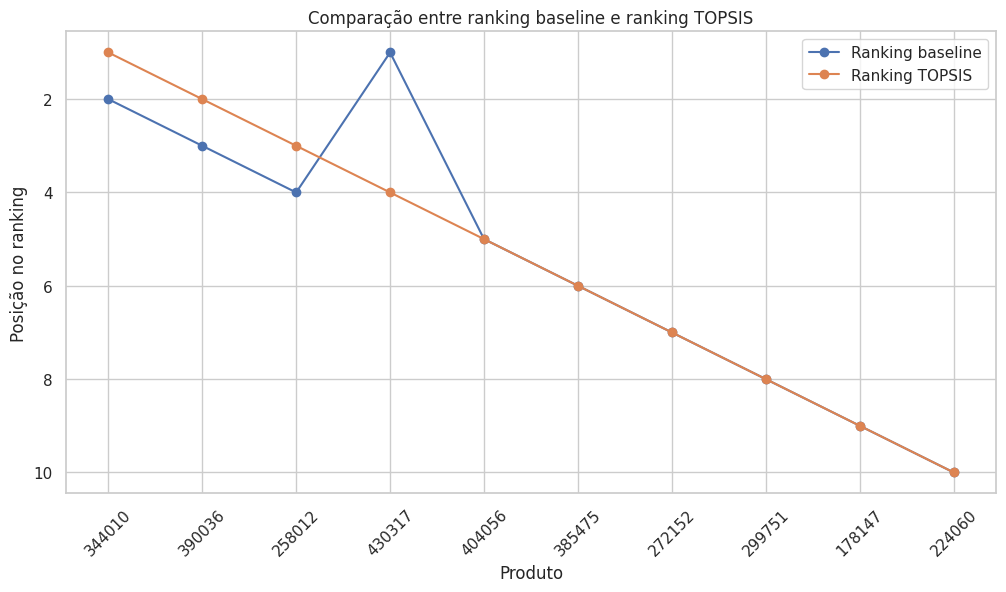

In [108]:
plot_comparison = comparison.copy()

plot_comparison['item_label'] = (
    plot_comparison['item_node']
    .str.replace('item_', '', regex=False)
)

plot_comparison = plot_comparison.sort_values(
    'topsis_rank',
    ascending=True
)

plt.figure(figsize=(12, 6))

x = np.arange(len(plot_comparison))

plt.plot(
    x,
    plot_comparison['baseline_rank'],
    marker='o',
    label='Ranking baseline'
)

plt.plot(
    x,
    plot_comparison['topsis_rank'],
    marker='o',
    label='Ranking TOPSIS'
)

plt.xticks(
    x,
    plot_comparison['item_label'],
    rotation=45
)

plt.gca().invert_yaxis()

plt.title('Comparação entre ranking baseline e ranking TOPSIS')
plt.xlabel('Produto')
plt.ylabel('Posição no ranking')
plt.legend()

plt.show()

### Salvando os resultados

In [109]:
topsis_results.to_csv(
    '/content/topsis_results.csv',
    index=False
)

comparison.to_csv(
    '/content/baseline_vs_topsis.csv',
    index=False
)

print('Resultados do TOPSIS salvos.')

Resultados do TOPSIS salvos.


## Etapa 5: Analisando os resultados

In [110]:
# Criando o ranking da baseline
baseline_rank = (
    baseline_recommendations[
        ['item_node']
    ]
    .reset_index(drop=True)
    .copy()
)

baseline_rank['baseline_rank'] = (
    baseline_rank.index + 1
)

display(baseline_rank)

,item_node,baseline_rank
0,item_430317,1
1,item_272152,2
2,item_344010,3
3,item_299751,4
4,item_385475,5
5,item_390036,6
6,item_178147,7
7,item_404056,8
8,item_224060,9
9,item_258012,10


In [111]:
# Selecionando o ranking TOPSIS
topsis_rank = topsis_results[
    [
        'item_node',
        'topsis_score',
        'topsis_rank'
    ]
].copy()

display(topsis_rank)

,item_node,topsis_score,topsis_rank
0,item_344010,0.724444,1
1,item_390036,0.595522,2
2,item_258012,0.299897,3
3,item_430317,0.278473,4
4,item_404056,0.229125,5
5,item_385475,0.174868,6
6,item_272152,0.046997,7
7,item_299751,0.046741,8
8,item_178147,0.001578,9
9,item_224060,0.001578,10


In [112]:
# Comparando os dois rankings
ranking_comparison = baseline_rank.merge(
    topsis_rank,
    on='item_node',
    how='inner'
)

ranking_comparison['rank_change'] = (
    ranking_comparison['baseline_rank']
    - ranking_comparison['topsis_rank']
)

ranking_comparison = ranking_comparison.sort_values(
    'topsis_rank'
)

display(ranking_comparison)

,item_node,baseline_rank,topsis_score,topsis_rank,rank_change
2,item_344010,3,0.724444,1,2
5,item_390036,6,0.595522,2,4
9,item_258012,10,0.299897,3,7
0,item_430317,1,0.278473,4,-3
7,item_404056,8,0.229125,5,3
4,item_385475,5,0.174868,6,-1
1,item_272152,2,0.046997,7,-5
3,item_299751,4,0.046741,8,-4
6,item_178147,7,0.001578,9,-2
8,item_224060,9,0.001578,10,-1


In [113]:
# Resumo das mudanças
number_up = (
    ranking_comparison['rank_change'] > 0
).sum()

number_down = (
    ranking_comparison['rank_change'] < 0
).sum()

number_equal = (
    ranking_comparison['rank_change'] == 0
).sum()

print('Produtos que subiram:', number_up)
print('Produtos que caíram:', number_down)
print('Produtos que permaneceram:', number_equal)

Produtos que subiram: 4
Produtos que caíram: 6
Produtos que permaneceram: 0


In [114]:
# Correlação entre os rankings
rank_correlation = ranking_comparison[
    ['baseline_rank', 'topsis_rank']
].corr(method='spearman').iloc[0, 1]

print(
    f'Correlação de Spearman entre os rankings: '
    f'{rank_correlation:.4f}'
)

Correlação de Spearman entre os rankings: 0.1879


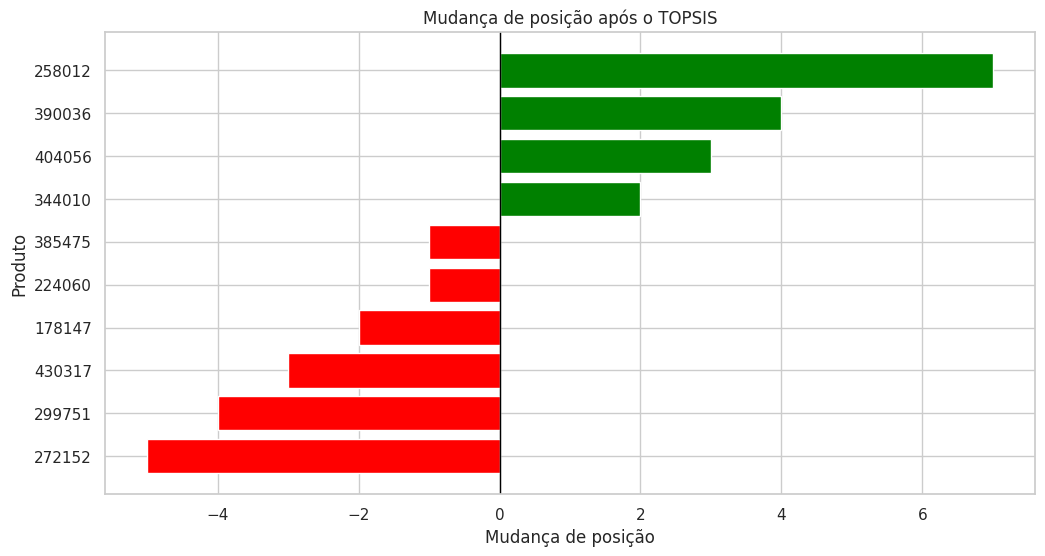

In [115]:
# Visualizando as mudanças
plot_data = ranking_comparison.copy()

plot_data['item_label'] = (
    plot_data['item_node']
    .str.replace('item_', '', regex=False)
)

plot_data = plot_data.sort_values(
    'rank_change'
)

colors = [
    'green' if value > 0
    else 'red' if value < 0
    else 'gray'
    for value in plot_data['rank_change']
]

plt.figure(figsize=(12, 6))

plt.barh(
    plot_data['item_label'],
    plot_data['rank_change'],
    color=colors
)

plt.axvline(
    0,
    color='black',
    linewidth=1
)

plt.title('Mudança de posição após o TOPSIS')
plt.xlabel('Mudança de posição')
plt.ylabel('Produto')

plt.show()

### Em vários visitantes, o TOPSIS recupera mais vezes o produto realmente comprado do que o baseline?

Avaliação preliminar com múltiplos visitantes :
*   Para cada visitante, a última transação será utilizada como item de teste.
*   Os eventos anteriores serão utilizados para construir o histórico e o grafo.

In [116]:
events = events.sort_values('datetime').copy()

all_transactions = events[
    events['event'] == 'transaction'
].copy()

# Última compra de cada visitante
test_transactions = (
    all_transactions
    .groupby('visitorid', as_index=False)
    .tail(1)
    .copy()
)

# Todos os eventos, exceto as últimas compras usadas no teste
train_events = events.drop(
    index=test_transactions.index
).copy()

print('Eventos de treinamento:', len(train_events))
print('Transações de teste:', len(test_transactions))
print('Visitantes de teste:', test_transactions['visitorid'].nunique())

Eventos de treinamento: 9346
Transações de teste: 39
Visitantes de teste: 39


In [117]:
# Reconstruindo o grafo apenas com dados de treinamento
def build_graph_structures(events_df):
    interactions = events_df[
        ['visitorid', 'itemid', 'event', 'datetime']
    ].dropna().copy()

    event_weights = {
        'view': 1.0,
        'addtocart': 3.0,
        'transaction': 5.0
    }

    interactions['edge_weight'] = (
        interactions['event']
        .map(event_weights)
        .fillna(0)
    )

    edge_data_local = (
        interactions
        .groupby(['visitorid', 'itemid'], as_index=False)
        .agg(
            weight=('edge_weight', 'sum'),
            interaction_count=('event', 'size'),
            last_interaction=('datetime', 'max')
        )
    )

    edge_data_local['visitor_node'] = (
        'visitor_' +
        edge_data_local['visitorid'].astype(str)
    )

    edge_data_local['item_node'] = (
        'item_' +
        edge_data_local['itemid'].astype(str)
    )

    graph = nx.Graph()

    visitor_nodes_local = (
        edge_data_local['visitor_node']
        .unique()
        .tolist()
    )

    item_nodes_local = (
        edge_data_local['item_node']
        .unique()
        .tolist()
    )

    graph.add_nodes_from(
        visitor_nodes_local,
        node_type='visitor',
        bipartite='visitor'
    )

    graph.add_nodes_from(
        item_nodes_local,
        node_type='item',
        bipartite='item'
    )

    for row in edge_data_local.itertuples(index=False):
        graph.add_edge(
            row.visitor_node,
            row.item_node,
            weight=float(row.weight),
            interaction_count=int(row.interaction_count),
            last_interaction=row.last_interaction
        )

    # Grafo produto-produto
    item_graph_local = nx.Graph()

    for visitor in visitor_nodes_local:
        visitor_products = list(graph.neighbors(visitor))

        if len(visitor_products) < 2:
            continue

        for item_a, item_b in combinations(
            sorted(visitor_products),
            2
        ):
            if item_graph_local.has_edge(item_a, item_b):
                item_graph_local[item_a][item_b]['weight'] += 1
            else:
                item_graph_local.add_edge(
                    item_a,
                    item_b,
                    weight=1.0
                )

    # PageRank
    pagerank_local = nx.pagerank(
        graph,
        alpha=0.85,
        weight='weight'
    )

    # Grau ponderado dos produtos
    item_degree_local = {
        item: graph.degree(item, weight='weight')
        for item in item_nodes_local
    }

    # Estatísticas comportamentais
    behavior = interactions.copy()

    behavior['item_node'] = (
        'item_' +
        behavior['itemid'].astype(str)
    )

    views = (
        behavior[behavior['event'] == 'view']
        .groupby('item_node')
        .size()
        .rename('views')
    )

    transactions = (
        behavior[behavior['event'] == 'transaction']
        .groupby('item_node')
        .size()
        .rename('transactions')
    )

    item_stats_local = pd.concat(
        [views, transactions],
        axis=1
    ).fillna(0)

    item_stats_local['conversion_rate'] = (
        item_stats_local['transactions'] /
        item_stats_local['views'].clip(lower=1)
    )

    last_interaction_local = (
        behavior
        .groupby('item_node')['datetime']
        .max()
        .rename('last_interaction')
    )

    item_stats_local = item_stats_local.join(
        last_interaction_local
    )

    reference_date = behavior['datetime'].max()

    item_stats_local['days_since_last_interaction'] = (
        reference_date -
        item_stats_local['last_interaction']
    ).dt.total_seconds() / (24 * 60 * 60)

    item_stats_local['recency_score'] = (
        1 /
        (1 + item_stats_local['days_since_last_interaction'])
    )

    return (
        edge_data_local,
        graph,
        item_graph_local,
        pagerank_local,
        item_degree_local,
        item_stats_local
    )

In [118]:
# Executando a construção
(
    edge_data_train,
    G_train,
    item_graph_train,
    pagerank_train,
    item_degree_train,
    item_stats_train
) = build_graph_structures(train_events)

print('Grafo de treinamento criado.')
print('Nós:', G_train.number_of_nodes())
print('Arestas:', G_train.number_of_edges())

Grafo de treinamento criado.
Nós: 11610
Arestas: 7390


In [119]:
# Criando a função baseline
def recommend_baseline_for_visitor(
    visitor_node,
    graph,
    item_graph,
    top_k=50
):
    if visitor_node not in graph:
        return pd.DataFrame(
            columns=[
                'item_node',
                'recommendation_score'
            ]
        )

    history = set(graph.neighbors(visitor_node))
    candidate_scores = {}

    for history_item in history:
        if history_item not in item_graph:
            continue

        for candidate in item_graph.neighbors(history_item):
            if candidate in history:
                continue

            weight = item_graph[
                history_item
            ][candidate]['weight']

            candidate_scores[candidate] = (
                candidate_scores.get(candidate, 0)
                + weight
            )

    if not candidate_scores:
        return pd.DataFrame(
            columns=[
                'item_node',
                'recommendation_score'
            ]
        )

    recommendations = pd.DataFrame(
        [
            {
                'item_node': item,
                'recommendation_score': score
            }
            for item, score in candidate_scores.items()
        ]
    )

    return (
        recommendations
        .sort_values(
            'recommendation_score',
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )

In [120]:
# Criando a função TOPSIS
def topsis_rerank(
    candidates,
    pagerank,
    item_degree,
    item_stats,
    top_k=10
):
    if candidates.empty:
        return []

    ranking_data = candidates.copy()

    ranking_data['pagerank'] = (
        ranking_data['item_node']
        .map(pagerank)
        .fillna(0)
    )

    ranking_data['weighted_degree'] = (
        ranking_data['item_node']
        .map(item_degree)
        .fillna(0)
    )

    stats_to_merge = item_stats[
        [
            'conversion_rate',
            'recency_score'
        ]
    ].copy()

    ranking_data = ranking_data.merge(
        stats_to_merge,
        left_on='item_node',
        right_index=True,
        how='left'
    )

    ranking_data = ranking_data.fillna(0)

    criteria = [
        'recommendation_score',
        'pagerank',
        'weighted_degree',
        'conversion_rate',
        'recency_score'
    ]

    weights = np.array([
        0.20,
        0.20,
        0.20,
        0.20,
        0.20
    ])

    matrix = ranking_data[criteria].astype(float).to_numpy()

    denominators = np.sqrt(
        (matrix ** 2).sum(axis=0)
    )

    denominators[denominators == 0] = 1

    normalized = matrix / denominators
    weighted = normalized * weights

    positive_ideal = weighted.max(axis=0)
    negative_ideal = weighted.min(axis=0)

    distance_positive = np.linalg.norm(
        weighted - positive_ideal,
        axis=1
    )

    distance_negative = np.linalg.norm(
        weighted - negative_ideal,
        axis=1
    )

    ranking_data['topsis_score'] = (
        distance_negative /
        (
            distance_positive +
            distance_negative +
            1e-12
        )
    )

    ranking_data = ranking_data.sort_values(
        'topsis_score',
        ascending=False
    )

    return ranking_data.head(top_k)

In [121]:
# Funções de avaliação
def reciprocal_rank(recommendations, target_item):
    for position, item in enumerate(recommendations, start=1):
        if item == target_item:
            return 1 / position

    return 0.0


def hit_at_k(recommendations, target_item, k=10):
    return int(target_item in recommendations[:k])


def ndcg_at_k(recommendations, target_item, k=10):
    recommendations = recommendations[:k]

    for position, item in enumerate(recommendations):
        if item == target_item:
            return 1 / np.log2(position + 2)

    return 0.0

In [122]:
# Executando a avaliação
evaluation_rows = []

for row in test_transactions.itertuples(index=False):

    visitor_node = (
        'visitor_' +
        str(row.visitorid)
    )

    target_item = (
        'item_' +
        str(row.itemid)
    )

    # O visitante precisa ter histórico no treinamento
    if visitor_node not in G_train:
        continue

    history_items = set(
        G_train.neighbors(visitor_node)
    )

    # Se o produto-alvo já estava no histórico,
    # não o usamos neste caso de recomendação nova
    if target_item in history_items:
        continue

    candidates = recommend_baseline_for_visitor(
        visitor_node=visitor_node,
        graph=G_train,
        item_graph=item_graph_train,
        top_k=50
    )

    if candidates.empty:
        continue

    baseline_recommendations = (
        candidates['item_node']
        .head(10)
        .tolist()
    )

    topsis_results_eval = topsis_rerank(
        candidates=candidates,
        pagerank=pagerank_train,
        item_degree=item_degree_train,
        item_stats=item_stats_train,
        top_k=10
    )

    topsis_recommendations = (
        topsis_results_eval['item_node']
        .tolist()
    )

    evaluation_rows.append({
        'visitorid': row.visitorid,
        'target_item': target_item,
        'baseline_hit@10': hit_at_k(
            baseline_recommendations,
            target_item,
            k=10
        ),
        'topsis_hit@10': hit_at_k(
            topsis_recommendations,
            target_item,
            k=10
        ),
        'baseline_ndcg@10': ndcg_at_k(
            baseline_recommendations,
            target_item,
            k=10
        ),
        'topsis_ndcg@10': ndcg_at_k(
            topsis_recommendations,
            target_item,
            k=10
        ),
        'baseline_mrr': reciprocal_rank(
            baseline_recommendations,
            target_item
        ),
        'topsis_mrr': reciprocal_rank(
            topsis_recommendations,
            target_item
        )
    })

evaluation_results = pd.DataFrame(evaluation_rows)

print('Casos avaliados:', len(evaluation_results))

display(evaluation_results.head())

Casos avaliados: 0


""


In [123]:
# Resumo dos resultados
if evaluation_results.empty:
    print(
        'Nenhum caso de teste válido foi encontrado. '
        'A amostra pode ser pequena ou não possuir histórico suficiente.'
    )
else:
    summary_metrics = pd.DataFrame({
        'métrica': [
            'HitRate@10',
            'NDCG@10',
            'MRR'
        ],
        'baseline': [
            evaluation_results['baseline_hit@10'].mean(),
            evaluation_results['baseline_ndcg@10'].mean(),
            evaluation_results['baseline_mrr'].mean()
        ],
        'topsis': [
            evaluation_results['topsis_hit@10'].mean(),
            evaluation_results['topsis_ndcg@10'].mean(),
            evaluation_results['topsis_mrr'].mean()
        ]
    })

    display(summary_metrics)

Nenhum caso de teste válido foi encontrado. A amostra pode ser pequena ou não possuir histórico suficiente.


In [124]:
# Diagnosticando
print('Transações de teste:', len(test_transactions))

test_visitors = set(
    'visitor_' + test_transactions['visitorid'].astype(str)
)

visitors_in_graph = sum(
    visitor in G_train
    for visitor in test_visitors
)

print('Visitantes de teste presentes no grafo de treino:', visitors_in_graph)

Transações de teste: 39
Visitantes de teste presentes no grafo de treino: 39


In [125]:
# Contando quantos produtos-alvo já estavam no histórico
target_already_seen = 0
target_not_seen = 0

for row in test_transactions.itertuples(index=False):

    visitor_node = 'visitor_' + str(row.visitorid)
    target_item = 'item_' + str(row.itemid)

    if visitor_node not in G_train:
        continue

    history_items = set(
        G_train.neighbors(visitor_node)
    )

    if target_item in history_items:
        target_already_seen += 1
    else:
        target_not_seen += 1

print('Alvo já visto anteriormente:', target_already_seen)
print('Alvo não visto anteriormente:', target_not_seen)

Alvo já visto anteriormente: 39
Alvo não visto anteriormente: 0


In [126]:
def recommend_baseline_for_visitor(
    visitor_node,
    graph,
    item_graph,
    excluded_items=None,
    top_k=50
):
    """
    Recomenda produtos com base na coocorrência no grafo.

    Produtos em excluded_items não serão recomendados.
    Produtos apenas visualizados podem continuar aparecendo.
    """

    if visitor_node not in graph:
        return pd.DataFrame(
            columns=[
                'item_node',
                'recommendation_score'
            ]
        )

    if excluded_items is None:
        excluded_items = set()
    else:
        excluded_items = set(excluded_items)

    # Histórico de produtos vistos, adicionados ao carrinho ou comprados
    history = set(
        graph.neighbors(visitor_node)
    )

    candidate_scores = {}

    for history_item in history:

        if history_item not in item_graph:
            continue

        for candidate in item_graph.neighbors(history_item):

            # Exclui somente produtos já comprados
            if candidate in excluded_items:
                continue

            relation_weight = item_graph[
                history_item
            ][candidate]['weight']

            candidate_scores[candidate] = (
                candidate_scores.get(candidate, 0)
                + relation_weight
            )

    if not candidate_scores:
        return pd.DataFrame(
            columns=[
                'item_node',
                'recommendation_score'
            ]
        )

    recommendations = pd.DataFrame(
        [
            {
                'item_node': item,
                'recommendation_score': score
            }
            for item, score in candidate_scores.items()
        ]
    )

    return (
        recommendations
        .sort_values(
            'recommendation_score',
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )

In [127]:
# Reexecutando a avaliação
evaluation_rows = []

for row in test_transactions.itertuples(index=False):

    visitor_node = (
        'visitor_' +
        str(row.visitorid)
    )

    target_item = (
        'item_' +
        str(row.itemid)
    )

    # O visitante precisa existir no grafo de treinamento
    if visitor_node not in G_train:
        continue

    # Produtos que o visitante já comprou antes
    previous_purchases = train_events[
        (train_events['visitorid'] == row.visitorid) &
        (train_events['event'] == 'transaction')
    ]['itemid'].astype(str)

    previous_purchases = {
        'item_' + item
        for item in previous_purchases
    }

    # Se o alvo já foi comprado antes, ignoramos este caso
    if target_item in previous_purchases:
        continue

    candidates = recommend_baseline_for_visitor(
        visitor_node=visitor_node,
        graph=G_train,
        item_graph=item_graph_train,
        excluded_items=previous_purchases,
        top_k=50
    )

    if candidates.empty:
        continue

    baseline_recommendations = (
        candidates['item_node']
        .head(10)
        .tolist()
    )

    topsis_results_eval = topsis_rerank(
        candidates=candidates,
        pagerank=pagerank_train,
        item_degree=item_degree_train,
        item_stats=item_stats_train,
        top_k=10
    )

    topsis_recommendations = (
        topsis_results_eval['item_node']
        .tolist()
    )

    evaluation_rows.append({
        'visitorid': row.visitorid,
        'target_item': target_item,

        'baseline_hit@10': hit_at_k(
            baseline_recommendations,
            target_item,
            k=10
        ),

        'topsis_hit@10': hit_at_k(
            topsis_recommendations,
            target_item,
            k=10
        ),

        'baseline_ndcg@10': ndcg_at_k(
            baseline_recommendations,
            target_item,
            k=10
        ),

        'topsis_ndcg@10': ndcg_at_k(
            topsis_recommendations,
            target_item,
            k=10
        ),

        'baseline_mrr': reciprocal_rank(
            baseline_recommendations,
            target_item
        ),

        'topsis_mrr': reciprocal_rank(
            topsis_recommendations,
            target_item
        )
    })

evaluation_results = pd.DataFrame(evaluation_rows)

print('Casos avaliados:', len(evaluation_results))

display(evaluation_results.head())

Casos avaliados: 25


,visitorid,target_item,baseline_hit@10,topsis_hit@10,baseline_ndcg@10,topsis_ndcg@10,baseline_mrr,topsis_mrr
0,1041562,item_22145,1,1,1.0,0.5,1.0,0.333333
1,1324552,item_212743,0,0,0.0,0.0,0.0,0.000000
2,766502,item_414995,0,0,0.0,0.0,0.0,0.000000
3,293600,item_55044,1,1,1.0,1.0,1.0,1.000000
4,343404,item_44220,1,1,1.0,1.0,1.0,1.000000


In [128]:
print('Transações de teste:', len(test_transactions))
print('Arestas no grafo de itens:', item_graph_train.number_of_edges())
print('Produtos no grafo de itens:', item_graph_train.number_of_nodes())

Transações de teste: 39
Arestas no grafo de itens: 8335
Produtos no grafo de itens: 3219


### Resumindo os resultados

In [129]:
# Calculando as médias gerais para comparar baseline e TOPSIS
summary_metrics = pd.DataFrame({
    'métrica': [
        'HitRate@10',
        'NDCG@10',
        'MRR'
    ],
    'baseline': [
        evaluation_results['baseline_hit@10'].mean(),
        evaluation_results['baseline_ndcg@10'].mean(),
        evaluation_results['baseline_mrr'].mean()
    ],
    'topsis': [
        evaluation_results['topsis_hit@10'].mean(),
        evaluation_results['topsis_ndcg@10'].mean(),
        evaluation_results['topsis_mrr'].mean()
    ]
})

display(summary_metrics)

,métrica,baseline,topsis
0,HitRate@10,0.920000,0.920000
1,NDCG@10,0.657147,0.773650
2,MRR,0.573333,0.724667


In [130]:
# Calculando:
# - quantos casos o TOPSIS venceu o baseline;
# - quantos casos empataram;
# - quantos casos o baseline venceu.

comparison_outcomes = pd.DataFrame({
    'resultado_hit': np.where(
        evaluation_results['topsis_hit@10'] > evaluation_results['baseline_hit@10'],
        'TOPSIS melhor',
        np.where(
            evaluation_results['topsis_hit@10'] < evaluation_results['baseline_hit@10'],
            'Baseline melhor',
            'Empate'
        )
    )
})

display(comparison_outcomes['resultado_hit'].value_counts())

,count
resultado_hit,
Empate,25


### Testando diferentes combinações de pesos
Verificando como elas afetam:
*   HitRate@10;
*   NDCG@10;
*   MRR.

In [131]:
# Função TOPSIS com pesos variáveis
def topsis_rerank_with_weights(
    candidates,
    pagerank,
    item_degree,
    item_stats,
    weights,
    top_k=10
):
    """
    Reordena candidatos usando TOPSIS
    com pesos definidos pelo usuário.
    """

    if candidates.empty:
        return pd.DataFrame()

    ranking_data = candidates.copy()

    ranking_data['pagerank'] = (
        ranking_data['item_node']
        .map(pagerank)
        .fillna(0)
    )

    ranking_data['weighted_degree'] = (
        ranking_data['item_node']
        .map(item_degree)
        .fillna(0)
    )

    stats_to_merge = item_stats[
        [
            'conversion_rate',
            'recency_score'
        ]
    ].copy()

    ranking_data = ranking_data.merge(
        stats_to_merge,
        left_on='item_node',
        right_index=True,
        how='left'
    )

    ranking_data = ranking_data.fillna(0)

    criteria = [
        'recommendation_score',
        'pagerank',
        'weighted_degree',
        'conversion_rate',
        'recency_score'
    ]

    matrix = ranking_data[criteria].astype(float).to_numpy()

    denominators = np.sqrt(
        (matrix ** 2).sum(axis=0)
    )

    denominators[denominators == 0] = 1

    normalized = matrix / denominators

    weight_vector = np.array([
        weights[criterion]
        for criterion in criteria
    ])

    weighted_matrix = normalized * weight_vector

    positive_ideal = weighted_matrix.max(axis=0)
    negative_ideal = weighted_matrix.min(axis=0)

    distance_positive = np.linalg.norm(
        weighted_matrix - positive_ideal,
        axis=1
    )

    distance_negative = np.linalg.norm(
        weighted_matrix - negative_ideal,
        axis=1
    )

    ranking_data['topsis_score'] = (
        distance_negative /
        (
            distance_positive +
            distance_negative +
            1e-12
        )
    )

    ranking_data = ranking_data.sort_values(
        'topsis_score',
        ascending=False
    ).reset_index(drop=True)

    ranking_data['topsis_rank'] = (
        ranking_data.index + 1
    )

    return ranking_data.head(top_k)

### Análise de sensibilidade dos pesos

Serão testados diferentes cenários de importância dos critérios.

Cada cenário mantém os mesmos candidatos e altera apenas os pesos utilizados
pelo TOPSIS.

In [132]:
# Criando os cenários
weight_scenarios = {
    'pesos_iguais': {
        'recommendation_score': 0.20,
        'pagerank': 0.20,
        'weighted_degree': 0.20,
        'conversion_rate': 0.20,
        'recency_score': 0.20
    },

    'historico_prioritario': {
        'recommendation_score': 0.40,
        'pagerank': 0.15,
        'weighted_degree': 0.15,
        'conversion_rate': 0.15,
        'recency_score': 0.15
    },

    'grafo_prioritario': {
        'recommendation_score': 0.15,
        'pagerank': 0.35,
        'weighted_degree': 0.30,
        'conversion_rate': 0.10,
        'recency_score': 0.10
    },

    'conversao_prioritaria': {
        'recommendation_score': 0.15,
        'pagerank': 0.15,
        'weighted_degree': 0.15,
        'conversion_rate': 0.40,
        'recency_score': 0.15
    },

    'recencia_prioritaria': {
        'recommendation_score': 0.15,
        'pagerank': 0.15,
        'weighted_degree': 0.15,
        'conversion_rate': 0.15,
        'recency_score': 0.40
    }
}

In [133]:
# Verificando se os pesos somam 1
for scenario_name, weights in weight_scenarios.items():
    print(
        scenario_name,
        '→ soma:',
        round(sum(weights.values()), 4)
    )

pesos_iguais → soma: 1.0
historico_prioritario → soma: 1.0
grafo_prioritario → soma: 1.0
conversao_prioritaria → soma: 1.0
recencia_prioritaria → soma: 1.0


In [134]:
# Executando a análise de sensibilidade
sensitivity_rows = []

for row in test_transactions.itertuples(index=False):

    visitor_node = (
        'visitor_' +
        str(row.visitorid)
    )

    target_item = (
        'item_' +
        str(row.itemid)
    )

    if visitor_node not in G_train:
        continue

    previous_purchases = train_events[
        (train_events['visitorid'] == row.visitorid) &
        (train_events['event'] == 'transaction')
    ]['itemid'].astype(str)

    previous_purchases = {
        'item_' + item
        for item in previous_purchases
    }

    if target_item in previous_purchases:
        continue

    candidates = recommend_baseline_for_visitor(
        visitor_node=visitor_node,
        graph=G_train,
        item_graph=item_graph_train,
        excluded_items=previous_purchases,
        top_k=50
    )

    if candidates.empty:
        continue

    baseline_recommendations = (
        candidates['item_node']
        .head(10)
        .tolist()
    )

    baseline_hit = hit_at_k(
        baseline_recommendations,
        target_item,
        k=10
    )

    baseline_ndcg = ndcg_at_k(
        baseline_recommendations,
        target_item,
        k=10
    )

    baseline_mrr = reciprocal_rank(
        baseline_recommendations,
        target_item
    )

    for scenario_name, weights in weight_scenarios.items():

        topsis_result = topsis_rerank_with_weights(
            candidates=candidates,
            pagerank=pagerank_train,
            item_degree=item_degree_train,
            item_stats=item_stats_train,
            weights=weights,
            top_k=10
        )

        if topsis_result.empty:
            continue

        topsis_recommendations = (
            topsis_result['item_node']
            .tolist()
        )

        sensitivity_rows.append({
            'scenario': scenario_name,
            'visitorid': row.visitorid,
            'target_item': target_item,

            'baseline_hit@10': baseline_hit,
            'topsis_hit@10': hit_at_k(
                topsis_recommendations,
                target_item,
                k=10
            ),

            'baseline_ndcg@10': baseline_ndcg,
            'topsis_ndcg@10': ndcg_at_k(
                topsis_recommendations,
                target_item,
                k=10
            ),

            'baseline_mrr': baseline_mrr,
            'topsis_mrr': reciprocal_rank(
                topsis_recommendations,
                target_item
            )
        })

sensitivity_results = pd.DataFrame(
    sensitivity_rows
)

print(
    'Linhas de resultados:',
    len(sensitivity_results)
)

display(sensitivity_results.head())

Linhas de resultados: 125


,scenario,visitorid,target_item,baseline_hit@10,topsis_hit@10,baseline_ndcg@10,topsis_ndcg@10,baseline_mrr,topsis_mrr
0,pesos_iguais,1041562,item_22145,1,1,1.0,0.50000,1.0,0.333333
1,historico_prioritario,1041562,item_22145,1,1,1.0,0.63093,1.0,0.500000
2,grafo_prioritario,1041562,item_22145,1,1,1.0,0.63093,1.0,0.500000
3,conversao_prioritaria,1041562,item_22145,1,1,1.0,0.50000,1.0,0.333333
4,recencia_prioritaria,1041562,item_22145,1,1,1.0,0.50000,1.0,0.333333


In [135]:
# Resumindo os resultados por cenário
sensitivity_summary = (
    sensitivity_results
    .groupby('scenario')
    .agg(
        casos=('visitorid', 'count'),

        baseline_hit_at_10=('baseline_hit@10', 'mean'),
        topsis_hit_at_10=('topsis_hit@10', 'mean'),

        baseline_ndcg_at_10=('baseline_ndcg@10', 'mean'),
        topsis_ndcg_at_10=('topsis_ndcg@10', 'mean'),

        baseline_mrr=('baseline_mrr', 'mean'),
        topsis_mrr=('topsis_mrr', 'mean')
    )
    .reset_index()
)

display(sensitivity_summary)

,scenario,casos,baseline_hit_at_10,topsis_hit_at_10,baseline_ndcg_at_10,topsis_ndcg_at_10,baseline_mrr,topsis_mrr
0,conversao_prioritaria,25,0.92,0.92,0.657147,0.773650,0.573333,0.724667
1,grafo_prioritario,25,0.92,0.92,0.657147,0.808413,0.573333,0.771333
2,historico_prioritario,25,0.92,0.92,0.657147,0.780640,0.573333,0.733333
3,pesos_iguais,25,0.92,0.92,0.657147,0.773650,0.573333,0.724667
4,recencia_prioritaria,25,0.92,0.92,0.657147,0.742457,0.573333,0.685048


In [136]:
# Calculando as diferenças
sensitivity_summary['delta_hit@10'] = (
    sensitivity_summary['topsis_hit_at_10'] -
    sensitivity_summary['baseline_hit_at_10']
)

sensitivity_summary['delta_ndcg@10'] = (
    sensitivity_summary['topsis_ndcg_at_10'] -
    sensitivity_summary['baseline_ndcg_at_10']
)

sensitivity_summary['delta_mrr'] = (
    sensitivity_summary['topsis_mrr'] -
    sensitivity_summary['baseline_mrr']
)

display(sensitivity_summary)

,scenario,casos,baseline_hit_at_10,topsis_hit_at_10,baseline_ndcg_at_10,topsis_ndcg_at_10,baseline_mrr,topsis_mrr,delta_hit@10,delta_ndcg@10,delta_mrr
0,conversao_prioritaria,25,0.92,0.92,0.657147,0.773650,0.573333,0.724667,0.0,0.116503,0.151333
1,grafo_prioritario,25,0.92,0.92,0.657147,0.808413,0.573333,0.771333,0.0,0.151266,0.198000
2,historico_prioritario,25,0.92,0.92,0.657147,0.780640,0.573333,0.733333,0.0,0.123493,0.160000
3,pesos_iguais,25,0.92,0.92,0.657147,0.773650,0.573333,0.724667,0.0,0.116503,0.151333
4,recencia_prioritaria,25,0.92,0.92,0.657147,0.742457,0.573333,0.685048,0.0,0.085311,0.111714


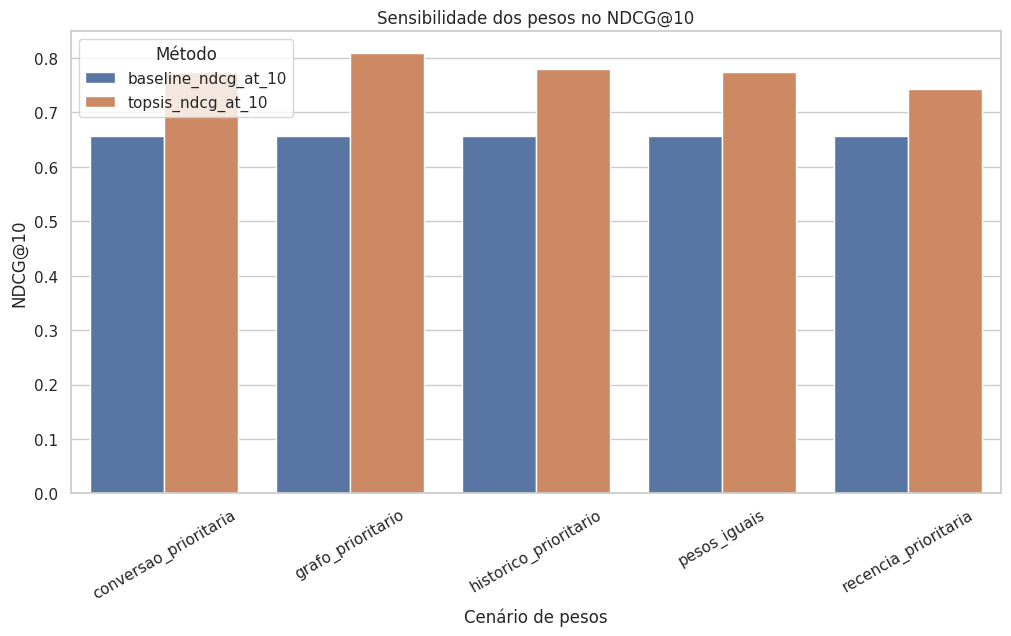

In [137]:
# Gráfico de comparação dos cenários
plot_sensitivity = sensitivity_summary.melt(
    id_vars='scenario',
    value_vars=[
        'baseline_ndcg_at_10',
        'topsis_ndcg_at_10'
    ],
    var_name='metodo',
    value_name='ndcg_at_10'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_sensitivity,
    x='scenario',
    y='ndcg_at_10',
    hue='metodo'
)

plt.title('Sensibilidade dos pesos no NDCG@10')
plt.xlabel('Cenário de pesos')
plt.ylabel('NDCG@10')
plt.xticks(rotation=30)
plt.legend(title='Método')

plt.show()

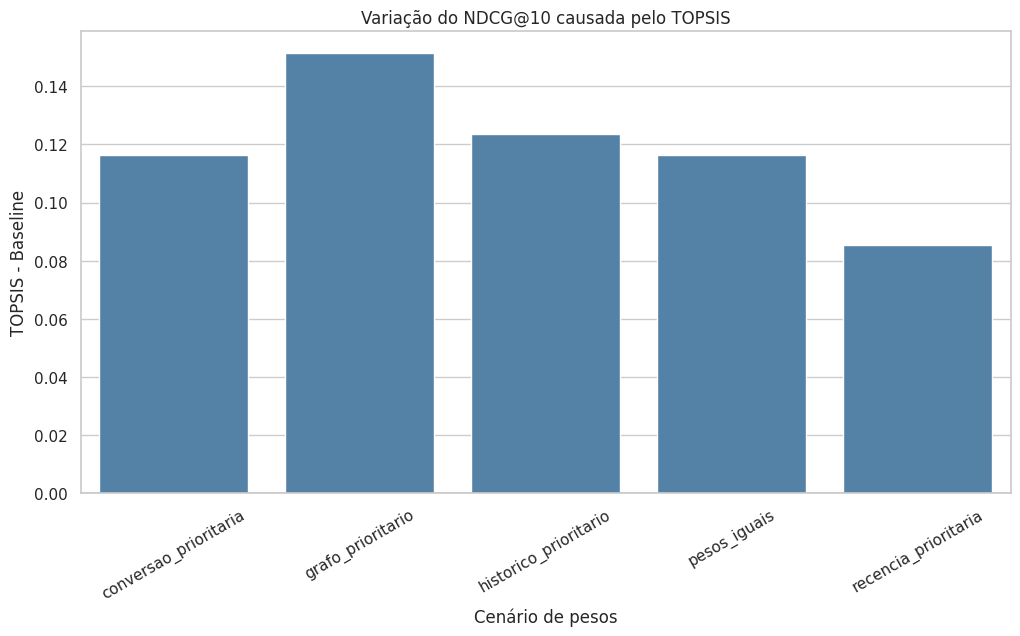

In [138]:
# Gráfico das diferenças do TOPSIS
plt.figure(figsize=(12, 6))

sns.barplot(
    data=sensitivity_summary,
    x='scenario',
    y='delta_ndcg@10',
    color='steelblue'
)

plt.axhline(
    0,
    color='black',
    linewidth=1
)

plt.title('Variação do NDCG@10 causada pelo TOPSIS')
plt.xlabel('Cenário de pesos')
plt.ylabel('TOPSIS - Baseline')
plt.xticks(rotation=30)

plt.show()

In [139]:
# Salvando os resultados
sensitivity_results.to_csv(
    '/content/topsis_sensitivity_details.csv',
    index=False
)

sensitivity_summary.to_csv(
    '/content/topsis_sensitivity_summary.csv',
    index=False
)

evaluation_results.to_csv(
    '/content/evaluation_results.csv',
    index=False
)

comparison.to_csv(
    '/content/ranking_comparison.csv',
    index=False
)

print('Arquivos salvos:')
print('- /content/topsis_sensitivity_details.csv')
print('- /content/topsis_sensitivity_summary.csv')
print('- /content/evaluation_results.csv')
print('- /content/ranking_comparison.csv')

Arquivos salvos:
- /content/topsis_sensitivity_details.csv
- /content/topsis_sensitivity_summary.csv
- /content/evaluation_results.csv
- /content/ranking_comparison.csv


## Síntese visual e textual dos resultados preliminares

In [140]:
# Preparando os dados para os gráficos
metric_records = []

for _, row in sensitivity_summary.iterrows():

    scenario = row['scenario']

    metric_records.extend([
        {
            'scenario': scenario,
            'metrica': 'HitRate@10',
            'metodo': 'Baseline',
            'valor': row['baseline_hit_at_10']
        },
        {
            'scenario': scenario,
            'metrica': 'HitRate@10',
            'metodo': 'TOPSIS',
            'valor': row['topsis_hit_at_10']
        },
        {
            'scenario': scenario,
            'metrica': 'NDCG@10',
            'metodo': 'Baseline',
            'valor': row['baseline_ndcg_at_10']
        },
        {
            'scenario': scenario,
            'metrica': 'NDCG@10',
            'metodo': 'TOPSIS',
            'valor': row['topsis_ndcg_at_10']
        },
        {
            'scenario': scenario,
            'metrica': 'MRR',
            'metodo': 'Baseline',
            'valor': row['baseline_mrr']
        },
        {
            'scenario': scenario,
            'metrica': 'MRR',
            'metodo': 'TOPSIS',
            'valor': row['topsis_mrr']
        }
    ])

metrics_long = pd.DataFrame(metric_records)

display(metrics_long.head(10))

,scenario,metrica,metodo,valor
0,conversao_prioritaria,HitRate@10,Baseline,0.920000
1,conversao_prioritaria,HitRate@10,TOPSIS,0.920000
2,conversao_prioritaria,NDCG@10,Baseline,0.657147
3,conversao_prioritaria,NDCG@10,TOPSIS,0.773650
4,conversao_prioritaria,MRR,Baseline,0.573333
5,conversao_prioritaria,MRR,TOPSIS,0.724667
6,grafo_prioritario,HitRate@10,Baseline,0.920000
7,grafo_prioritario,HitRate@10,TOPSIS,0.920000
8,grafo_prioritario,NDCG@10,Baseline,0.657147
9,grafo_prioritario,NDCG@10,TOPSIS,0.808413


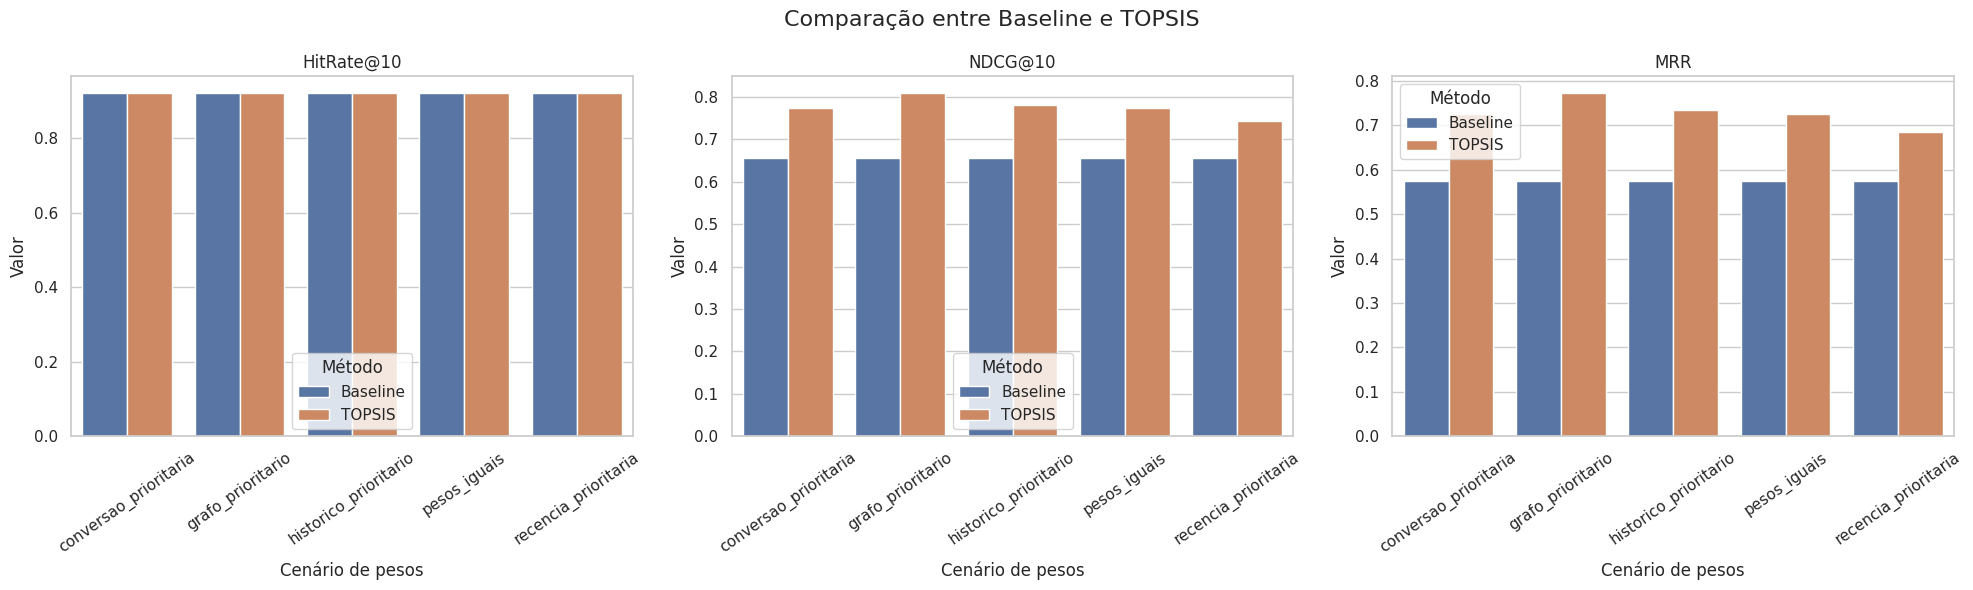

In [141]:
# Gráfico geral das métricas
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 6)
)

metrics_to_plot = [
    'HitRate@10',
    'NDCG@10',
    'MRR'
]

for ax, metric in zip(axes, metrics_to_plot):

    plot_data = metrics_long[
        metrics_long['metrica'] == metric
    ]

    sns.barplot(
        data=plot_data,
        x='scenario',
        y='valor',
        hue='metodo',
        ax=ax
    )

    ax.set_title(metric)
    ax.set_xlabel('Cenário de pesos')
    ax.set_ylabel('Valor')
    ax.tick_params(
        axis='x',
        rotation=35
    )

    ax.legend(title='Método')

plt.suptitle(
    'Comparação entre Baseline e TOPSIS',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [142]:
# identificando o melhor cenário
best_scenario_row = (
    sensitivity_summary
    .sort_values(
        'topsis_ndcg_at_10',
        ascending=False
    )
    .iloc[0]
)

best_scenario = best_scenario_row['scenario']

best_ndcg = (
    best_scenario_row['topsis_ndcg_at_10']
)

best_mrr = (
    best_scenario_row['topsis_mrr']
)

baseline_ndcg = (
    best_scenario_row['baseline_ndcg_at_10']
)

baseline_mrr = (
    best_scenario_row['baseline_mrr']
)

delta_ndcg = best_ndcg - baseline_ndcg
delta_mrr = best_mrr - baseline_mrr

print('Melhor cenário:', best_scenario)
print(f'NDCG@10 do TOPSIS: {best_ndcg:.6f}')
print(f'NDCG@10 do baseline: {baseline_ndcg:.6f}')
print(f'Delta de NDCG@10: {delta_ndcg:.6f}')
print(f'MRR do TOPSIS: {best_mrr:.6f}')
print(f'MRR do baseline: {baseline_mrr:.6f}')
print(f'Delta de MRR: {delta_mrr:.6f}')

Melhor cenário: grafo_prioritario
NDCG@10 do TOPSIS: 0.808413
NDCG@10 do baseline: 0.657147
Delta de NDCG@10: 0.151266
MRR do TOPSIS: 0.771333
MRR do baseline: 0.573333
Delta de MRR: 0.198000


In [143]:
# Tabela final resumida
final_summary = sensitivity_summary.copy()

final_summary['melhoria_ndcg_percentual'] = (
    (
        final_summary['topsis_ndcg_at_10'] -
        final_summary['baseline_ndcg_at_10']
    )
    /
    final_summary['baseline_ndcg_at_10']
    * 100
)

final_summary['melhoria_mrr_percentual'] = (
    (
        final_summary['topsis_mrr'] -
        final_summary['baseline_mrr']
    )
    /
    final_summary['baseline_mrr']
    * 100
)

final_summary = final_summary.sort_values(
    'topsis_ndcg_at_10',
    ascending=False
)

display(final_summary)

,scenario,casos,baseline_hit_at_10,topsis_hit_at_10,baseline_ndcg_at_10,topsis_ndcg_at_10,baseline_mrr,topsis_mrr,delta_hit@10,delta_ndcg@10,delta_mrr,melhoria_ndcg_percentual,melhoria_mrr_percentual
1,grafo_prioritario,25,0.92,0.92,0.657147,0.808413,0.573333,0.771333,0.0,0.151266,0.198000,23.018597,34.534884
2,historico_prioritario,25,0.92,0.92,0.657147,0.780640,0.573333,0.733333,0.0,0.123493,0.160000,18.792346,27.906977
0,conversao_prioritaria,25,0.92,0.92,0.657147,0.773650,0.573333,0.724667,0.0,0.116503,0.151333,17.728636,26.395349
3,pesos_iguais,25,0.92,0.92,0.657147,0.773650,0.573333,0.724667,0.0,0.116503,0.151333,17.728636,26.395349
4,recencia_prioritaria,25,0.92,0.92,0.657147,0.742457,0.573333,0.685048,0.0,0.085311,0.111714,12.981971,19.485050


In [144]:
# Gerando a interpretação automática dos resultados
best_row = final_summary.iloc[0]

scenario = best_row['scenario']

baseline_hit = best_row['baseline_hit_at_10']
topsis_hit = best_row['topsis_hit_at_10']

baseline_ndcg = best_row['baseline_ndcg_at_10']
topsis_ndcg = best_row['topsis_ndcg_at_10']

baseline_mrr = best_row['baseline_mrr']
topsis_mrr = best_row['topsis_mrr']

delta_ndcg = topsis_ndcg - baseline_ndcg
delta_mrr = topsis_mrr - baseline_mrr

preliminary_interpretation = f"""
Interpretação preliminar dos resultados

Foram avaliados {int(best_row['casos'])} casos.

O HitRate@10 do baseline foi {baseline_hit:.4f},
enquanto o TOPSIS apresentou {topsis_hit:.4f}.

O NDCG@10 do baseline foi {baseline_ndcg:.6f},
enquanto o TOPSIS apresentou {topsis_ndcg:.6f}.

A diferença de NDCG@10 foi de {delta_ndcg:.6f}.

O MRR do baseline foi {baseline_mrr:.6f},
enquanto o TOPSIS apresentou {topsis_mrr:.6f}.

A diferença de MRR foi de {delta_mrr:.6f}.

O melhor cenário de pesos, considerando o NDCG@10,
foi: {scenario}.

De forma preliminar, os resultados indicam que o TOPSIS
não aumentou necessariamente a quantidade de acertos no Top-10,
mas melhorou a posição dos itens relevantes no ranking.
"""

print(preliminary_interpretation)


Interpretação preliminar dos resultados

Foram avaliados 25 casos.

O HitRate@10 do baseline foi 0.9200,
enquanto o TOPSIS apresentou 0.9200.

O NDCG@10 do baseline foi 0.657147,
enquanto o TOPSIS apresentou 0.808413.

A diferença de NDCG@10 foi de 0.151266.

O MRR do baseline foi 0.573333,
enquanto o TOPSIS apresentou 0.771333.

A diferença de MRR foi de 0.198000.

O melhor cenário de pesos, considerando o NDCG@10,
foi: grafo_prioritario.

De forma preliminar, os resultados indicam que o TOPSIS
não aumentou necessariamente a quantidade de acertos no Top-10,
mas melhorou a posição dos itens relevantes no ranking.



In [ ]:
# Salvando
final_summary.to_csv(
    '/content/final_summary_preliminary.csv',
    index=False
)

with open(
    '/content/preliminary_interpretation.txt',
    'w',
    encoding='utf-8'
) as file:
    file.write(preliminary_interpretation)

print('Arquivos salvos:')
print('- /content/final_summary_preliminary.csv')
print('- /content/preliminary_interpretation.txt')

In [ ]:
# Salvando as tabelas principais

final_summary.to_csv(
    '/content/final_summary_preliminary.csv',
    index=False
)

sensitivity_summary.to_csv(
    '/content/topsis_sensitivity_summary.csv',
    index=False
)

sensitivity_results.to_csv(
    '/content/topsis_sensitivity_details.csv',
    index=False
)

evaluation_results.to_csv(
    '/content/evaluation_results.csv',
    index=False
)

ranking_comparison.to_csv(
    '/content/ranking_comparison.csv',
    index=False
)

metrics_long.to_csv(
    '/content/metrics_long.csv',
    index=False
)

# Salvando o texto interpretativo
with open('/content/preliminary_interpretation.txt', 'w', encoding='utf-8') as f:
    f.write(preliminary_interpretation)

# Salvando um resumo curto em texto
resume_text = f"""
Resumo dos resultados preliminares

Melhor cenário: {best_scenario}

HitRate@10 baseline: {baseline_hit:.4f}
HitRate@10 TOPSIS: {topsis_hit:.4f}

NDCG@10 baseline: {baseline_ndcg:.6f}
NDCG@10 TOPSIS: {topsis_ndcg:.6f}
Delta NDCG@10: {delta_ndcg:.6f}

MRR baseline: {baseline_mrr:.6f}
MRR TOPSIS: {topsis_mrr:.6f}
Delta MRR: {delta_mrr:.6f}
"""

with open('/content/preliminary_resume.txt', 'w', encoding='utf-8') as f:
    f.write(resume_text)

print('Arquivos salvos com sucesso:')
print('- /content/final_summary_preliminary.csv')
print('- /content/topsis_sensitivity_summary.csv')
print('- /content/topsis_sensitivity_details.csv')
print('- /content/evaluation_results.csv')
print('- /content/ranking_comparison.csv')
print('- /content/metrics_long.csv')
print('- /content/preliminary_interpretation.txt')
print('- /content/preliminary_resume.txt')

In [ ]:
# Baixando todos os arquivos
from google.colab import files

files.download('/content/final_summary_preliminary.csv')
files.download('/content/topsis_sensitivity_summary.csv')
files.download('/content/topsis_sensitivity_details.csv')
files.download('/content/evaluation_results.csv')
files.download('/content/ranking_comparison.csv')
files.download('/content/metrics_long.csv')
files.download('/content/preliminary_interpretation.txt')
files.download('/content/preliminary_resume.txt')

## Síntese preliminar

Os experimentos preliminares indicam que o TOPSIS não alterou a taxa de acerto no Top-10,
mas melhorou a qualidade da ordenação dos itens relevantes.

O melhor cenário encontrado foi aquele em que os critérios estruturais do grafo receberam maior peso.
Nessa configuração, houve ganho em NDCG@10 e MRR, sugerindo que a integração entre coocorrência,
centralidade e comportamento é mais eficaz do que a ordenação original do baseline.

Como os testes foram feitos em uma amostra pequena, os resultados devem ser interpretados como
exploratórios e validados posteriormente em uma amostra maior.

# Trabalhando com o dataset completo

## Experimento final

As células anteriores utilizaram uma amostra reduzida para desenvolvimento.
A partir desta seção, o pipeline será executado sobre o dataset completo.

A amostra será preservada na variável `events_sample`.

In [145]:
events_sample = events.copy()

print('Amostra preservada.')
print('Eventos:', len(events_sample))

Amostra preservada.
Eventos: 9385


A partir de agora:
*   events_sample → amostra do GitHub
*   events_full   → dataset completo
*   events_active → dataset atualmente usado

## Instruções para carregar os dados

Este projeto possui dois modos de execução.

### Modo demonstração

O modo demonstração utiliza uma amostra reduzida hospedada no GitHub.
Essa opção permite executar o notebook rapidamente sem baixar o dataset completo.

### Modo completo

O modo completo utiliza o dataset original do Retailrocket.

O dataset completo não está armazenado neste repositório porque os arquivos são
grandes. Para executar o experimento final, o pesquisador deve:

1. Baixar o dataset original a partir do Kaggle em: `https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset?resource=download`
2. Obter o arquivo `events.csv`.
3. Disponibilizar o arquivo no ambiente de execução do Colab.

O arquivo pode ser disponibilizado de três formas:

- upload temporário para o Colab;
- armazenamento em uma pasta do Google Drive;
- download automatizado usando a API do Kaggle.

O upload temporário não exige acesso ao Google Drive, mas será necessário repetir o upload quando a sessão do Colab for encerrada ou reiniciada.

O Google Drive é opcional e facilita a persistência dos arquivos, mas exige
autorização de acesso ao Drive pelo Colab.

O dataset completo não deve ser incluído no repositório GitHub.

In [146]:
# Localizando o arquivo .zip com o dataset completo
from pathlib import Path

zip_files = list(Path('/content').rglob('*.zip'))

print('Arquivos ZIP encontrados:')
for file in zip_files:
    print(file)

Arquivos ZIP encontrados:
/content/retailrocket.zip


In [147]:
# Descompactando o .zip
from pathlib import Path
import zipfile
import shutil

zip_path = Path(file)
extract_dir = Path('/content/retailrocket_full')

if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print('ZIP descompactado em:', extract_dir)

# Vendo o que foi extraído
for file in extract_dir.rglob('*'):
    print(file)

ZIP descompactado em: /content/retailrocket_full
/content/retailrocket_full/retailrocket
/content/retailrocket_full/retailrocket/events.csv
/content/retailrocket_full/retailrocket/item_properties_part1.csv
/content/retailrocket_full/retailrocket/item_properties_part2.csv
/content/retailrocket_full/retailrocket/category_tree.csv


In [148]:
# Definindo o caminho correto do `events.csv`
full_events_path = Path('/content/retailrocket_full/retailrocket/events.csv')

In [149]:
# Carregando o dataset completo
import pandas as pd

events_full = pd.read_csv(
    full_events_path,
    low_memory=False
)

events_full['datetime'] = pd.to_datetime(
    events_full['timestamp'],
    unit='ms',
    errors='coerce'
)

print('Dataset completo carregado.')
print('Eventos:', f'{len(events_full):,}')
print('Visitantes:', f"{events_full['visitorid'].nunique():,}")
print('Produtos:', f"{events_full['itemid'].nunique():,}")

Dataset completo carregado.
Eventos: 2,756,101
Visitantes: 1,407,580
Produtos: 235,061


In [150]:
# Comparando amostra e dataset completo
comparison_dataset_sizes = pd.DataFrame({
    'base': ['Amostra', 'Dataset completo'],
    'eventos': [
        len(events_sample),
        len(events_full)
    ],
    'visitantes': [
        events_sample['visitorid'].nunique(),
        events_full['visitorid'].nunique()
    ],
    'produtos': [
        events_sample['itemid'].nunique(),
        events_full['itemid'].nunique()
    ],
    'transacoes': [
        events_sample['transactionid'].notna().sum(),
        events_full['transactionid'].notna().sum()
    ]
})

display(comparison_dataset_sizes)

,base,eventos,visitantes,produtos,transacoes
0,Amostra,9385,5000,6610,46
1,Dataset completo,2756101,1407580,235061,22457


In [151]:
# Escolhendo o modo ativo
DATA_MODE = 'full'  # troque para 'sample' se quiser testar a amostra

if DATA_MODE == 'sample':
    events_active = events_sample.copy()
elif DATA_MODE == 'full':
    events_active = events_full.copy()
else:
    raise ValueError("DATA_MODE deve ser 'sample' ou 'full'.")

print('Modo ativo:', DATA_MODE)
print('Eventos ativos:', f'{len(events_active):,}')
print('Visitantes ativos:', f"{events_active['visitorid'].nunique():,}")
print('Produtos ativos:', f"{events_active['itemid'].nunique():,}")

Modo ativo: full
Eventos ativos: 2,756,101
Visitantes ativos: 1,407,580
Produtos ativos: 235,061


In [152]:
# Validando o dataset ativo
dataset_summary_active = pd.DataFrame({
    'indicador': [
        'Eventos',
        'Visitantes únicos',
        'Produtos únicos',
        'Transações identificadas',
        'Data inicial',
        'Data final'
    ],
    'valor': [
        len(events_active),
        events_active['visitorid'].nunique(),
        events_active['itemid'].nunique(),
        events_active['transactionid'].notna().sum(),
        events_active['datetime'].min(),
        events_active['datetime'].max()
    ]
})

display(dataset_summary_active)

,indicador,valor
0,Eventos,2756101
1,Visitantes únicos,1407580
2,Produtos únicos,235061
3,Transações identificadas,22457
4,Data inicial,2015-05-03 03:00:04.384000
5,Data final,2015-09-18 02:59:47.788000


## Reconstruindo grafo, baseline e TOPSIS

In [ ]:
# Divisão temporal para avaliação fora da amostra

events_evaluation = events_active.sort_values(
    by='datetime'
).copy()

cutoff_date = events_evaluation['datetime'].quantile(0.80)

events_train = events_evaluation[
    events_evaluation['datetime'] <= cutoff_date
].copy()

events_test = events_evaluation[
    events_evaluation['datetime'] > cutoff_date
].copy()

print('Data de corte:', cutoff_date)
print('Eventos de treino:', f'{len(events_train):,}')
print('Eventos de teste:', f'{len(events_test):,}')

print(
    'Transações no treino:',
    f"{(events_train['event'] == 'transaction').sum():,}"
)

print(
    'Transações no teste:',
    f"{(events_test['event'] == 'transaction').sum():,}"
)

In [ ]:
# Construindo o grafo de treino
# Consolidando as relações visitante-produto do conjunto de treino

user_item_train = (
    events_train_graph
    .groupby(
        ['visitorid', 'itemid'],
        as_index=False
    )
    .agg(
        interaction_weight=('interaction_weight', 'sum'),
        event_count=('event', 'size')
    )
)

print(
    'Relações únicas no treino:',
    f'{len(user_item_train):,}'
)

In [ ]:
# Criando a matriz esparsa do grafo de treino

from scipy.sparse import coo_matrix

user_codes_train, user_ids_train = pd.factorize(
    user_item_train['visitorid']
)

item_codes_train, item_ids_train = pd.factorize(
    user_item_train['itemid']
)

train_graph_matrix = coo_matrix(
    (
        user_item_train['interaction_weight'].to_numpy(),
        (user_codes_train, item_codes_train)
    ),
    shape=(
        len(user_ids_train),
        len(item_ids_train)
    )
).tocsr()

print('Grafo de treino criado.')
print(
    'Visitantes:',
    f'{train_graph_matrix.shape[0]:,}'
)
print(
    'Produtos:',
    f'{train_graph_matrix.shape[1]:,}'
)
print(
    'Arestas:',
    f'{train_graph_matrix.nnz:,}'
)

In [ ]:
# Calculando grau dos produtos

degree_train = np.asarray(
    train_graph_matrix.getnnz(axis=0)
).ravel()

weighted_degree_train = np.asarray(
    train_graph_matrix.sum(axis=0)
).ravel()

graph_metrics_train = pd.DataFrame({
    'itemid': item_ids_train,
    'degree': degree_train,
    'weighted_degree': weighted_degree_train
})

print('Métricas de grau calculadas.')

display(
    graph_metrics_train.head()
)

In [ ]:
# Calculando PageRank dos produtos

damping = 0.85
max_iterations = 100
tolerance = 1e-10

num_users, num_items = train_graph_matrix.shape
num_nodes = num_users + num_items

user_weighted_degree = np.asarray(
    train_graph_matrix.sum(axis=1)
).ravel()

item_weighted_degree = np.asarray(
    train_graph_matrix.sum(axis=0)
).ravel()

user_weighted_degree[
    user_weighted_degree == 0
] = 1

item_weighted_degree[
    item_weighted_degree == 0
] = 1

# Inicialização uniforme
pagerank_users = np.full(
    num_users,
    1 / num_nodes
)

pagerank_items = np.full(
    num_items,
    1 / num_nodes
)

teleport = (1 - damping) / num_nodes

for iteration in range(max_iterations):

    new_pagerank_users = (
        teleport
        + damping * (
            train_graph_matrix
            @ (
                pagerank_items
                / item_weighted_degree
            )
        )
    )

    new_pagerank_items = (
        teleport
        + damping * (
            train_graph_matrix.T
            @ (
                pagerank_users
                / user_weighted_degree
            )
        )
    )

    error = (
        np.abs(
            new_pagerank_users
            - pagerank_users
        ).sum()
        + np.abs(
            new_pagerank_items
            - pagerank_items
        ).sum()
    )

    pagerank_users = new_pagerank_users
    pagerank_items = new_pagerank_items

    if error < tolerance:
        break

graph_metrics_train['pagerank'] = (
    pagerank_items
)

print(
    'PageRank calculado em',
    iteration + 1,
    'iterações.'
)

display(
    graph_metrics_train
    .sort_values(
        by='pagerank',
        ascending=False
    )
    .head(20)
)

In [ ]:
# Incorporando Grau e PageRank às métricas dos produtos

item_metrics_train_graph = (
    item_metrics_train
    .drop(
        columns=[
            'degree',
            'weighted_degree',
            'pagerank'
        ],
        errors='ignore'
    )
    .merge(
        graph_metrics_train,
        on='itemid',
        how='left'
    )
)

print(
    'Produtos com métricas completas:',
    f'{len(item_metrics_train_graph):,}'
)

display(
    item_metrics_train_graph.head()
)



---



In [153]:
# Preparando as interações do dataset ativo

import numpy as np
import pandas as pd

events_graph = events_active[
    ['visitorid', 'itemid', 'event', 'datetime']
].dropna(
    subset=['visitorid', 'itemid']
).copy()

# Pesos utilizados nas interações
event_weights = {
    'view': 1.0,
    'addtocart': 3.0,
    'transaction': 5.0
}

events_graph['interaction_weight'] = (
    events_graph['event']
    .map(event_weights)
    .fillna(0.0)
)

# Remove eventos sem peso reconhecido
events_graph = events_graph[
    events_graph['interaction_weight'] > 0
].copy()

print('Interações preparadas:', f'{len(events_graph):,}')
print(events_graph['event'].value_counts())

Interações preparadas: 2,756,101
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [154]:
# Agregando as relações entre visitantes e produtos

user_item_interactions = (
    events_graph
    .groupby(
        ['visitorid', 'itemid'],
        as_index=False
    )
    .agg(
        interaction_weight=('interaction_weight', 'sum'),
        event_count=('event', 'size'),
        last_datetime=('datetime', 'max')
    )
)

print(
    'Relações únicas visitante-produto:',
    f'{len(user_item_interactions):,}'
)

user_item_interactions.head()

Relações únicas visitante-produto: 2,145,179


,visitorid,itemid,interaction_weight,event_count,last_datetime
0,0,67045,1.0,1,2015-09-11 20:55:17.175
1,0,285930,1.0,1,2015-09-11 20:49:49.439
2,0,357564,1.0,1,2015-09-11 20:52:39.591
3,1,72028,1.0,1,2015-08-13 17:46:06.444
4,2,216305,2.0,2,2015-08-07 18:17:43.170


In [155]:
# Criando o grafo bipartido usuário-produto

from scipy.sparse import coo_matrix

user_codes, user_ids = pd.factorize(
    user_item_interactions['visitorid']
)

item_codes, item_ids = pd.factorize(
    user_item_interactions['itemid']
)

graph_matrix = coo_matrix(
    (
        user_item_interactions['interaction_weight'].to_numpy(),
        (user_codes, item_codes)
    ),
    shape=(len(user_ids), len(item_ids))
).tocsr()

print('Grafo criado.')
print('Visitantes no grafo:', f'{graph_matrix.shape[0]:,}')
print('Produtos no grafo:', f'{graph_matrix.shape[1]:,}')
print('Arestas:', f'{graph_matrix.nnz:,}')

Grafo criado.
Visitantes no grafo: 1,407,580
Produtos no grafo: 235,061
Arestas: 2,145,179


In [156]:
# Criando métricas de popularidade e engajamento dos produtos

item_metrics = (
    events_graph
    .groupby('itemid')
    .agg(
        total_events=('itemid', 'size'),
        unique_visitors=('visitorid', 'nunique'),
        views=('event', lambda x: (x == 'view').sum()),
        addtocart=('event', lambda x: (x == 'addtocart').sum()),
        transactions=('event', lambda x: (x == 'transaction').sum()),
        interaction_weight=('interaction_weight', 'sum')
    )
    .reset_index()
)

print(
    'Produtos com métricas:',
    f'{len(item_metrics):,}'
)

item_metrics.head()

Produtos com métricas: 235,061


,itemid,total_events,unique_visitors,views,addtocart,transactions,interaction_weight
0,3,2,2,2,0,0,2.0
1,4,3,3,3,0,0,3.0
2,6,29,26,29,0,0,29.0
3,9,2,2,2,0,0,2.0
4,15,22,13,18,3,1,32.0


In [157]:
# Baseline: ranking por popularidade

baseline_results = (
    item_metrics
    .sort_values(
        by=[
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_results['baseline_rank'] = (
    baseline_results.index + 1
)

print('Top 20 produtos do baseline:')

display(
    baseline_results[
        [
            'baseline_rank',
            'itemid',
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ]
    ].head(20)
)

Top 20 produtos do baseline:


,baseline_rank,itemid,transactions,addtocart,views,unique_visitors
0,1,461686,133,306,2539,1393
1,2,119736,97,44,752,267
2,3,213834,92,17,293,258
3,4,312728,46,162,947,615
4,5,7943,46,97,1346,846
5,6,445351,45,89,939,636
6,7,48030,41,95,986,634
7,8,420960,38,60,796,373
8,9,248455,38,52,575,292
9,10,17478,37,72,631,381


In [158]:
# Aplicando TOPSIS para ranquear os produtos

topsis_criteria = [
    'unique_visitors',
    'views',
    'addtocart',
    'transactions',
    'interaction_weight'
]

topsis_weights = np.array([
    0.20,
    0.15,
    0.20,
    0.30,
    0.15
])

X = item_metrics[topsis_criteria].astype(float)

# Normalização vetorial
norms = np.sqrt((X ** 2).sum(axis=0))
norms = norms.replace(0, 1)

R = X / norms

# Aplicação dos pesos
V = R * topsis_weights

# Todos os critérios são de benefício:
# quanto maior, melhor
ideal_solution = V.max(axis=0)
anti_ideal_solution = V.min(axis=0)

distance_ideal = np.sqrt(
    ((V - ideal_solution) ** 2).sum(axis=1)
)

distance_anti_ideal = np.sqrt(
    ((V - anti_ideal_solution) ** 2).sum(axis=1)
)

denominator = distance_ideal + distance_anti_ideal
denominator = denominator.replace(0, 1)

item_metrics['topsis_score'] = (
    distance_anti_ideal / denominator
)

topsis_results = (
    item_metrics
    .sort_values(
        by='topsis_score',
        ascending=False
    )
    .reset_index(drop=True)
)

topsis_results['topsis_rank'] = (
    topsis_results.index + 1
)

print('Top 20 produtos pelo TOPSIS:')

display(
    topsis_results[
        [
            'topsis_rank',
            'itemid',
            'topsis_score',
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ]
    ].head(20)
)

Top 20 produtos pelo TOPSIS:


,topsis_rank,itemid,topsis_score,transactions,addtocart,views,unique_visitors
0,1,461686,0.855217,133,306,2539,1393
1,2,119736,0.502022,97,44,752,267
2,3,213834,0.462150,92,17,293,258
3,4,312728,0.380382,46,162,947,615
4,5,7943,0.341619,46,97,1346,846
5,6,320130,0.323729,33,141,1333,886
6,7,409804,0.320509,35,156,647,457
7,8,445351,0.316068,45,89,939,636
8,9,48030,0.302983,41,95,986,634
9,10,187946,0.302322,0,2,3410,2912


In [159]:
# Comparando baseline e TOPSIS -> OUTER

baseline_top = baseline_results[
    ['itemid', 'baseline_rank']
].head(20)

topsis_top = topsis_results[
    ['itemid', 'topsis_rank', 'topsis_score']
].head(20)

ranking_comparison = baseline_top.merge(
    topsis_top,
    on='itemid',
    how='outer'
).sort_values(
    by=['baseline_rank', 'topsis_rank'],
    na_position='last'
)

display(ranking_comparison.head(30))

,itemid,baseline_rank,topsis_rank,topsis_score
23,461686,1.0,1.0,0.855217
7,119736,2.0,2.0,0.502022
9,213834,3.0,3.0,0.462150
13,312728,4.0,4.0,0.380382
1,7943,5.0,5.0,0.341619
22,445351,6.0,8.0,0.316068
6,48030,7.0,9.0,0.302983
20,420960,8.0,13.0,0.252917
10,248455,9.0,16.0,0.241831
2,17478,10.0,12.0,0.253188


In [160]:
# Comparando baseline e TOPSIS -> INNER

baseline_top20 = (
    baseline_results
    .head(20)[
        [
            'itemid',
            'baseline_rank',
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ]
    ]
)

topsis_top20 = (
    topsis_results
    .head(20)[
        [
            'itemid',
            'topsis_rank',
            'topsis_score'
        ]
    ]
)

top20_comparison_clean = (
    baseline_top20
    .merge(
        topsis_top20,
        on='itemid',
        how='inner'
    )
    .sort_values(
        by='topsis_rank'
    )
    .reset_index(drop=True)
)

display(top20_comparison_clean)

,itemid,baseline_rank,transactions,addtocart,views,unique_visitors,topsis_rank,topsis_score
0,461686,1,133,306,2539,1393,1,0.855217
1,119736,2,97,44,752,267,2,0.502022
2,213834,3,92,17,293,258,3,0.462150
3,312728,4,46,162,947,615,4,0.380382
4,7943,5,46,97,1346,846,5,0.341619
5,320130,12,33,141,1333,886,6,0.323729
6,409804,11,35,156,647,457,7,0.320509
7,445351,6,45,89,939,636,8,0.316068
8,48030,7,41,95,986,634,9,0.302983
9,257040,19,27,89,1531,986,11,0.263286


In [161]:
# Identificando produtos exclusivos de cada Top 20

baseline_ids = set(
    baseline_results.head(20)['itemid']
)

topsis_ids = set(
    topsis_results.head(20)['itemid']
)

only_baseline = baseline_ids - topsis_ids
only_topsis = topsis_ids - baseline_ids

exclusive_results = pd.DataFrame({
    'grupo': (
        ['Apenas baseline'] * len(only_baseline)
        + ['Apenas TOPSIS'] * len(only_topsis)
    ),
    'itemid': list(only_baseline) + list(only_topsis)
})

display(
    exclusive_results.sort_values(
        by=['grupo', 'itemid']
    ).reset_index(drop=True)
)

,grupo,itemid
0,Apenas TOPSIS,5411
1,Apenas TOPSIS,29196
2,Apenas TOPSIS,187946
3,Apenas TOPSIS,384302
4,Apenas baseline,46156
5,Apenas baseline,268883
6,Apenas baseline,334401
7,Apenas baseline,416017


## Avaliação formal

In [162]:
# Preparando a comparação completa entre baseline e TOPSIS

ranking_completo = (
    baseline_results[
        ['itemid', 'baseline_rank']
    ]
    .merge(
        topsis_results[
            ['itemid', 'topsis_rank', 'topsis_score']
        ],
        on='itemid',
        how='inner'
    )
)

# Mudança positiva significa que o produto subiu no TOPSIS
ranking_completo['mudanca_posicao'] = (
    ranking_completo['baseline_rank']
    - ranking_completo['topsis_rank']
)

print(
    'Produtos comparados:',
    f"{len(ranking_completo):,}"
)

ranking_completo.head()

Produtos comparados: 235,061


,itemid,baseline_rank,topsis_rank,topsis_score,mudanca_posicao
0,461686,1,1,0.855217,0
1,119736,2,2,0.502022,0
2,213834,3,3,0.462150,0
3,312728,4,4,0.380382,0
4,7943,5,5,0.341619,0


In [163]:
# Medindo a sobreposição entre os rankings

top_k_values = [5, 10, 20, 50, 100]
overlap_results = []

for k in top_k_values:
    baseline_top_k = set(
        baseline_results
        .head(k)['itemid']
    )

    topsis_top_k = set(
        topsis_results
        .head(k)['itemid']
    )

    intersection = (
        baseline_top_k
        .intersection(topsis_top_k)
    )

    union = (
        baseline_top_k
        .union(topsis_top_k)
    )

    overlap_results.append({
        'k': k,
        'produtos_baseline': len(baseline_top_k),
        'produtos_topsis': len(topsis_top_k),
        'produtos_em_comum': len(intersection),
        'percentual_sobreposicao': (
            len(intersection) / k * 100
        ),
        'indice_jaccard': (
            len(intersection) / len(union)
        )
    })

overlap_results = pd.DataFrame(overlap_results)

display(overlap_results)

,k,produtos_baseline,produtos_topsis,produtos_em_comum,percentual_sobreposicao,indice_jaccard
0,5,5,5,5,100.0,1.000000
1,10,10,10,7,70.0,0.538462
2,20,20,20,16,80.0,0.666667
3,50,50,50,35,70.0,0.538462
4,100,100,100,71,71.0,0.550388


In [164]:
# Medindo a correlação entre as posições dos produtos

from scipy.stats import spearmanr, kendalltau

spearman_result = spearmanr(
    ranking_completo['baseline_rank'],
    ranking_completo['topsis_rank']
)

kendall_result = kendalltau(
    ranking_completo['baseline_rank'],
    ranking_completo['topsis_rank']
)

correlation_results = pd.DataFrame({
    'medida': [
        'Correlação de Spearman',
        'Correlação de Kendall'
    ],
    'coeficiente': [
        spearman_result.statistic,
        kendall_result.statistic
    ],
    'p_valor': [
        spearman_result.pvalue,
        kendall_result.pvalue
    ]
})

display(correlation_results)

,medida,coeficiente,p_valor
0,Correlação de Spearman,0.966899,0.0
1,Correlação de Kendall,0.866189,0.0


In [165]:
# Identificando os produtos que mais subiram ou caíram

movement_results = (
    ranking_completo
    .sort_values(
        by='mudanca_posicao',
        ascending=False
    )
)

print('Produtos que mais subiram no TOPSIS:')

display(
    movement_results[
        [
            'itemid',
            'baseline_rank',
            'topsis_rank',
            'mudanca_posicao',
            'topsis_score'
        ]
    ].head(20)
)

print('Produtos que mais caíram no TOPSIS:')

display(
    movement_results[
        [
            'itemid',
            'baseline_rank',
            'topsis_rank',
            'mudanca_posicao',
            'topsis_score'
        ]
    ].tail(20)
)

Produtos que mais subiram no TOPSIS:


,itemid,baseline_rank,topsis_rank,mudanca_posicao,topsis_score
235056,466828,235057,161654,73403,0.000058
235055,466823,235056,161655,73401,0.000058
235054,466820,235055,161656,73399,0.000058
235053,466817,235054,161657,73397,0.000058
235052,466815,235053,161658,73395,0.000058
235051,466807,235052,161659,73393,0.000058
235039,466774,235040,161660,73380,0.000058
235038,466769,235039,161661,73378,0.000058
235037,466762,235038,161662,73376,0.000058
235036,466755,235037,161663,73374,0.000058


Produtos que mais caíram no TOPSIS:


,itemid,baseline_rank,topsis_rank,mudanca_posicao,topsis_score
161677,185,161678,234914,-73236,0.000058
161676,173,161677,234915,-73238,0.000058
161675,170,161676,234916,-73240,0.000058
161674,169,161675,234917,-73242,0.000058
161672,153,161673,234941,-73268,0.000058
161671,152,161672,234942,-73270,0.000058
161670,143,161671,234943,-73272,0.000058
161669,139,161670,234944,-73274,0.000058
161673,162,161674,234965,-73291,0.000058
161668,136,161669,234989,-73320,0.000058


In [166]:
# Comparação detalhada dos produtos presentes no Top 20

baseline_top20 = (
    baseline_results
    .head(20)[
        [
            'itemid',
            'baseline_rank',
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ]
    ]
)

topsis_top20 = (
    topsis_results
    .head(20)[
        [
            'itemid',
            'topsis_rank',
            'topsis_score'
        ]
    ]
)

top20_comparison = (
    baseline_top20
    .merge(
        topsis_top20,
        on='itemid',
        how='outer'
    )
    .sort_values(
        by='topsis_rank',
        na_position='last'
    )
)

display(top20_comparison)

,itemid,baseline_rank,transactions,addtocart,views,unique_visitors,topsis_rank,topsis_score
23,461686,1.0,133.0,306.0,2539.0,1393.0,1.0,0.855217
7,119736,2.0,97.0,44.0,752.0,267.0,2.0,0.502022
9,213834,3.0,92.0,17.0,293.0,258.0,3.0,0.462150
13,312728,4.0,46.0,162.0,947.0,615.0,4.0,0.380382
1,7943,5.0,46.0,97.0,1346.0,846.0,5.0,0.341619
14,320130,12.0,33.0,141.0,1333.0,886.0,6.0,0.323729
18,409804,11.0,35.0,156.0,647.0,457.0,7.0,0.320509
22,445351,6.0,45.0,89.0,939.0,636.0,8.0,0.316068
6,48030,7.0,41.0,95.0,986.0,634.0,9.0,0.302983
8,187946,NaN,NaN,NaN,NaN,NaN,10.0,0.302322


In [167]:
# Resumo numérico da comparação

top20_baseline = set(
    baseline_results.head(20)['itemid']
)

top20_topsis = set(
    topsis_results.head(20)['itemid']
)

top20_common = (
    top20_baseline
    .intersection(top20_topsis)
)

top20_only_baseline = (
    top20_baseline
    - top20_topsis
)

top20_only_topsis = (
    top20_topsis
    - top20_baseline
)

print('Resumo da comparação')
print('-' * 40)
print(
    'Produtos no Top 20 do baseline:',
    len(top20_baseline)
)
print(
    'Produtos no Top 20 do TOPSIS:',
    len(top20_topsis)
)
print(
    'Produtos em comum:',
    len(top20_common)
)
print(
    'Apenas no baseline:',
    len(top20_only_baseline)
)
print(
    'Apenas no TOPSIS:',
    len(top20_only_topsis)
)
print(
    'Sobreposição:',
    f'{len(top20_common) / 20 * 100:.2f}%'
)

Resumo da comparação
----------------------------------------
Produtos no Top 20 do baseline: 20
Produtos no Top 20 do TOPSIS: 20
Produtos em comum: 16
Apenas no baseline: 4
Apenas no TOPSIS: 4
Sobreposição: 80.00%


## Verificando se a ordenação TOPSIS é mais eficaz que a baseline

Divisão temporal estabelecendo dados de treino e dados de teste.

In [171]:
# Divisão temporal para avaliação fora da amostra

events_evaluation = events_active.sort_values(
    by='datetime'
).copy()

cutoff_date = events_evaluation['datetime'].quantile(0.80)

events_train = events_evaluation[
    events_evaluation['datetime'] <= cutoff_date
].copy()

events_test = events_evaluation[
    events_evaluation['datetime'] > cutoff_date
].copy()

print('Data de corte:', cutoff_date)
print('Eventos de treino:', f'{len(events_train):,}')
print('Eventos de teste:', f'{len(events_test):,}')

print(
    'Transações no treino:',
    f"{(events_train['event'] == 'transaction').sum():,}"
)

print(
    'Transações no teste:',
    f"{(events_test['event'] == 'transaction').sum():,}"
)

Data de corte: 2015-08-18 04:23:31.966000128
Eventos de treino: 2,204,881
Eventos de teste: 551,220
Transações no treino: 17,864
Transações no teste: 4,593


In [172]:
# Preparando as interações usando somente o conjunto de treino

events_train_graph = events_train[
    ['visitorid', 'itemid', 'event', 'datetime']
].dropna(
    subset=['visitorid', 'itemid']
).copy()

event_weights_train = {
    'view': 1.0,
    'addtocart': 3.0,
    'transaction': 5.0
}

events_train_graph['interaction_weight'] = (
    events_train_graph['event']
    .map(event_weights_train)
    .fillna(0.0)
)

events_train_graph = events_train_graph[
    events_train_graph['interaction_weight'] > 0
].copy()

print(
    'Interações de treino:',
    f'{len(events_train_graph):,}'
)

print(
    events_train_graph['event']
    .value_counts()
)

Interações de treino: 2,204,881
event
view           2132032
addtocart        54985
transaction      17864
Name: count, dtype: int64


In [175]:
# Recalculando as métricas dos produtos usando somente o treino

item_metrics_train = (
    events_train_graph
    .groupby('itemid')
    .agg(
        total_events=('itemid', 'size'),
        unique_visitors=('visitorid', 'nunique'),
        views=('event', lambda x: (x == 'view').sum()),
        addtocart=('event', lambda x: (x == 'addtocart').sum()),
        transactions=('event', lambda x: (x == 'transaction').sum()),
        interaction_weight=('interaction_weight', 'sum')
    )
    .reset_index()
)

print(
    'Produtos nas métricas de treino:',
    f'{len(item_metrics_train):,}'
)

display(item_metrics_train.head())

Produtos nas métricas de treino: 212,916


,itemid,total_events,unique_visitors,views,addtocart,transactions,interaction_weight
0,4,1,1,1,0,0,1.0
1,6,27,24,27,0,0,27.0
2,9,2,2,2,0,0,2.0
3,15,22,13,18,3,1,32.0
4,16,14,13,14,0,0,14.0


In [174]:
# Recalculando o baseline usando somente os dados de treino

baseline_results_train = (
    item_metrics_train
    .sort_values(
        by=[
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_results_train['baseline_rank'] = (
    baseline_results_train.index + 1
)

print('Top 20 do baseline de treino:')

display(
    baseline_results_train[
        [
            'baseline_rank',
            'itemid',
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ]
    ].head(20)
)

Top 20 do baseline de treino:


,baseline_rank,itemid,transactions,addtocart,views,unique_visitors
0,1,461686,92,222,1701,966
1,2,119736,75,36,598,221
2,3,213834,59,8,196,171
3,4,445351,43,81,823,558
4,5,48030,40,94,961,614
5,6,7943,40,81,1133,687
6,7,420960,35,54,709,323
7,8,17478,34,65,588,355
8,9,312728,31,143,787,525
9,10,369447,31,80,1093,607


In [176]:
# Recalculando o TOPSIS usando somente os dados de treino

topsis_criteria_train = [
    'unique_visitors',
    'views',
    'addtocart',
    'transactions',
    'interaction_weight'
]

topsis_weights_train = np.array([
    0.20,
    0.15,
    0.20,
    0.30,
    0.15
])

X_train = item_metrics_train[
    topsis_criteria_train
].astype(float)

# Normalização vetorial
norms_train = np.sqrt(
    (X_train ** 2).sum(axis=0)
)

norms_train = norms_train.replace(
    0,
    1
)

R_train = X_train / norms_train

# Aplicação dos pesos
V_train = R_train * topsis_weights_train

# Todos os critérios são de benefício
ideal_train = V_train.max(axis=0)
anti_ideal_train = V_train.min(axis=0)

distance_ideal_train = np.sqrt(
    ((V_train - ideal_train) ** 2).sum(axis=1)
)

distance_anti_ideal_train = np.sqrt(
    ((V_train - anti_ideal_train) ** 2).sum(axis=1)
)

denominator_train = (
    distance_ideal_train
    + distance_anti_ideal_train
)

denominator_train = denominator_train.replace(
    0,
    1
)

item_metrics_train['topsis_score'] = (
    distance_anti_ideal_train
    / denominator_train
)

topsis_results_train = (
    item_metrics_train
    .sort_values(
        by='topsis_score',
        ascending=False
    )
    .reset_index(drop=True)
)

topsis_results_train['topsis_rank'] = (
    topsis_results_train.index + 1
)

print('Top 20 do TOPSIS de treino:')

display(
    topsis_results_train[
        [
            'topsis_rank',
            'itemid',
            'topsis_score',
            'transactions',
            'addtocart',
            'views',
            'unique_visitors'
        ]
    ].head(20)
)

Top 20 do TOPSIS de treino:


,topsis_rank,itemid,topsis_score,transactions,addtocart,views,unique_visitors
0,1,461686,0.868597,92,222,1701,966
1,2,119736,0.546193,75,36,598,221
2,3,213834,0.434044,59,8,196,171
3,4,48030,0.426767,40,94,961,614
4,5,445351,0.425968,43,81,823,558
5,6,7943,0.420595,40,81,1133,687
6,7,312728,0.419749,31,143,787,525
7,8,257040,0.372748,27,89,1497,972
8,9,409804,0.370258,26,136,508,378
9,10,369447,0.356068,31,80,1093,607


In [177]:
# Comparando baseline e TOPSIS calculados apenas no treino

ranking_train = (
    baseline_results_train[
        ['itemid', 'baseline_rank']
    ]
    .merge(
        topsis_results_train[
            ['itemid', 'topsis_rank', 'topsis_score']
        ],
        on='itemid',
        how='inner'
    )
)

ranking_train['mudanca_posicao'] = (
    ranking_train['baseline_rank']
    - ranking_train['topsis_rank']
)

print(
    'Produtos comparados no treino:',
    f'{len(ranking_train):,}'
)

display(
    ranking_train
    .sort_values('topsis_rank')
    .head(20)
)

Produtos comparados no treino: 212,916


,itemid,baseline_rank,topsis_rank,topsis_score,mudanca_posicao
0,461686,1,1,0.868597,0
1,119736,2,2,0.546193,0
2,213834,3,3,0.434044,0
4,48030,5,4,0.426767,1
3,445351,4,5,0.425968,-1
5,7943,6,6,0.420595,0
8,312728,9,7,0.419749,2
12,257040,13,8,0.372748,5
13,409804,14,9,0.370258,5
9,369447,10,10,0.356068,0
